In [2]:
%pip install netCDF4 h5netcdf

Note: you may need to restart the kernel to use updated packages.


In [3]:
# ============================================================
# Import Packages And Notebook Setup
# ============================================================
# Purpose:
#   Load all libraries used later for NetCDF handling, plotting, statistics, and machine learning.
# Key variables:
#   - `os`, `glob`: find local NetCDF files
#   - `numpy`, `pandas`: array and table operations
#   - `xarray`: open and subset climate model datasets
#   - `matplotlib`, `seaborn`: plotting
#   - `scipy.stats`: trends and probability density estimates
#   - `sklearn` models/metrics/scaler: train and evaluate ML models
# Why this step:
#   - keeping imports in one place removes repetition and makes the notebook easier to audit
#   - the plotting theme is set once so every figure has the same style

import os
import glob
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import gaussian_kde
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})


In [4]:
# ============================================================
# Define Shared Paths, Study Location, And Core Variables
# ============================================================
# Purpose:
#   Store the file location, Manchester coordinates, and the climate variables reused throughout the notebook.
# Key variables:
#   - `DATA_DIR`: folder containing the NetCDF files
#   - `NC_FILES`: sorted list of climate files
#   - `MEMBER_IDS`: ensemble member labels from the filenames
#   - `MAN_LAT`, `MAN_LON`: Manchester grid-point target
#   - `ALL_VARS`: variables to extract once and reuse later
#   - `FEATURE_VARS`: predictors for the Tmax model
# Why this step:
#   - defining these once avoids repeating the same constants in multiple places
#   - using one Manchester grid point keeps the case study focused and consistent across EDA and ML

DATA_DIR = "."
NC_FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.nc*")))

print(f"Looking for NetCDF files in: {os.path.abspath(DATA_DIR)}")
print(f"Found {len(NC_FILES)} file(s):")
for f in NC_FILES:
    print(" -", os.path.basename(f))

if len(NC_FILES) == 0:
    raise FileNotFoundError("No NetCDF files found in the current folder.")

MEMBER_IDS = [os.path.basename(f).split("_")[0] for f in NC_FILES]
MAN_LAT = 53.48
MAN_LON = 357.76

ALL_VARS = ["TREFMXAV_U", "TREFHT", "FSNS", "QBOT", "FLNS", "UBOT", "VBOT", "PRECT", "PRSN"]
FEATURE_VARS = ["TREFHT", "FSNS", "QBOT", "FLNS", "UBOT", "VBOT", "PRECT", "PRSN"]


Looking for NetCDF files in: /Users/edward/Desktop/Curriculum/EART60702/project_2
Found 6 file(s):
 - 003_2006_2080_352_360.nc
 - 004_2006_2080_352_360.nc
 - 005_2006_2080_352_360.nc
 - 006_2006_2080_352_360.nc
 - 007_2006_2080_352_360.nc
 - 008_2006_2080_352_360.nc


In [5]:
# ============================================================
# Helper Function To Open NetCDF Files
# ============================================================
# Purpose:
#   Try the supported NetCDF engines in order and stop with a clear error if neither works.
# Key variables:
#   - `fpath`: path to one NetCDF file
#   - `engines`: candidate backends (`netcdf4`, `h5netcdf`)
#   - `last_error`: saved so failures are easier to debug
# Why this step:
#   - different local Python setups sometimes support different NetCDF backends
#   - wrapping the logic in one function keeps file opening consistent everywhere

def open_nc_file(fpath):
    engines = ["netcdf4", "h5netcdf"]
    last_error = None

    for engine in engines:
        try:
            return xr.open_dataset(fpath, engine=engine, decode_times=True)
        except Exception as e:
            last_error = e

    raise RuntimeError(
        f"Could not open {os.path.basename(fpath)} with netcdf4 or h5netcdf. "
        f"Last error: {last_error}"
    )


In [6]:
# ============================================================
# Load And Preprocess The Shared Climate Table
# ============================================================
# Purpose:
#   Read every ensemble member, subset Manchester, convert variables into analysis-ready columns, and combine everything into `data`.
# Key variables:
#   - `frames`: list of member-level dataframes before concatenation
#   - `df`: one member extracted at the Manchester grid point
#   - `data`: final combined table used by every later section
#   - `TREFMXAV_U_C`, `TREFHT_C`: Celsius versions used for interpretation
# Why this step:
#   - loading once avoids repeated file I/O later in the notebook
#   - keeping all members together makes ensemble summaries and ML training much easier

print("\nLoading data for all ensemble members...")
frames = []

for mid, fpath in zip(MEMBER_IDS, NC_FILES):
    try:
        print(f"\nLoading member {mid}: {os.path.basename(fpath)}")
        ds = open_nc_file(fpath)

        required_coords = ["lat", "lon", "time"]
        for c in required_coords:
            if c not in ds.coords and c not in ds.variables:
                raise ValueError(f"Missing required coordinate/variable: {c}")

        for v in ALL_VARS:
            if v not in ds.variables:
                raise ValueError(f"Missing required variable: {v}")

        sel = ds[ALL_VARS].sel(lat=MAN_LAT, lon=MAN_LON, method="nearest")
        df = sel.to_dataframe().reset_index()

        if df.empty:
            print(f"Skipping {mid}: dataframe is empty")
            ds.close()
            continue

        df["year"] = [t.year for t in df["time"]]
        df["month"] = [t.month for t in df["time"]]
        df["doy"] = [t.timetuple().tm_yday for t in df["time"]]
        df["member"] = mid
        df["TREFMXAV_U_C"] = df["TREFMXAV_U"] - 273.15
        if "TREFHT" in df.columns:
            df["TREFHT_C"] = df["TREFHT"] - 273.15

        frames.append(df)
        print(f"Loaded {len(df):,} rows for member {mid}")
        ds.close()

    except Exception as e:
        print(f"Error loading {os.path.basename(fpath)}: {e}")
        continue

if len(frames) == 0:
    raise ValueError(
        "No valid datasets were loaded. Check that the files contain all required coordinates and climate variables."
    )

data = pd.concat(frames, ignore_index=True)
print(f"\nLoaded {len(data):,} rows in total")
print(f"Loaded {data['member'].nunique()} ensemble members")
print(f"Years covered: {data['year'].min()} to {data['year'].max()}")



Loading data for all ensemble members...

Loading member 003: 003_2006_2080_352_360.nc
Loaded 27,374 rows for member 003

Loading member 004: 004_2006_2080_352_360.nc
Loaded 27,374 rows for member 004

Loading member 005: 005_2006_2080_352_360.nc
Loaded 27,374 rows for member 005

Loading member 006: 006_2006_2080_352_360.nc
Loaded 27,374 rows for member 006

Loading member 007: 007_2006_2080_352_360.nc
Loaded 27,374 rows for member 007

Loading member 008: 008_2006_2080_352_360.nc
Loaded 27,374 rows for member 008

Loaded 164,244 rows in total
Loaded 6 ensemble members
Years covered: 2006 to 2080


In [7]:
# ============================================================
# Temperature EDA: Summary Statistics
# ============================================================
# Purpose:
#   Summarise Manchester daily maximum temperature and split it into historical and projected periods.
# Key variables:
#   - `data`: full Manchester table
#   - `hist`, `proj`: historical (<=2049) and projected (>=2050) subsets
#   - `TREFMXAV_U_C`: target variable in Celsius
# Why this step:
#   - this gives an immediate overview before plotting trends
#   - the period split is reused throughout the rest of the temperature EDA

hist = data[data["year"] <= 2049].copy()
proj = data[data["year"] >= 2050].copy()

print("\nTREFMXAV_U summary (Celsius):\n")

print("Overall:")
print(data["TREFMXAV_U_C"].describe().round(2))

print("\nHistorical (2006-2049) vs Projected (2050-2080):")
summary = (
    data.assign(period=data["year"].map(lambda y: "2006-2049" if y <= 2049 else "2050-2080"))
    .groupby("period")["TREFMXAV_U_C"]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)
print(summary)

print("\nPer-member means in the projected period:")
print(
    data[data["year"] >= 2050]
    .groupby("member")["TREFMXAV_U_C"]
    .mean()
    .round(2)
)



TREFMXAV_U summary (Celsius):

Overall:
count    164244.00
mean         15.75
std           5.23
min          -1.82
25%          11.67
50%          15.24
75%          19.82
max          38.11
Name: TREFMXAV_U_C, dtype: float64

Historical (2006-2049) vs Projected (2050-2080):
                mean   std   min        max
period                                     
2006-2049  15.060000  5.00 -1.82  35.250000
2050-2080  16.719999  5.41  1.20  38.110001

Per-member means in the projected period:
member
003    16.730000
004    16.680000
005    16.709999
006    16.860001
007    16.629999
008    16.680000
Name: TREFMXAV_U_C, dtype: float32


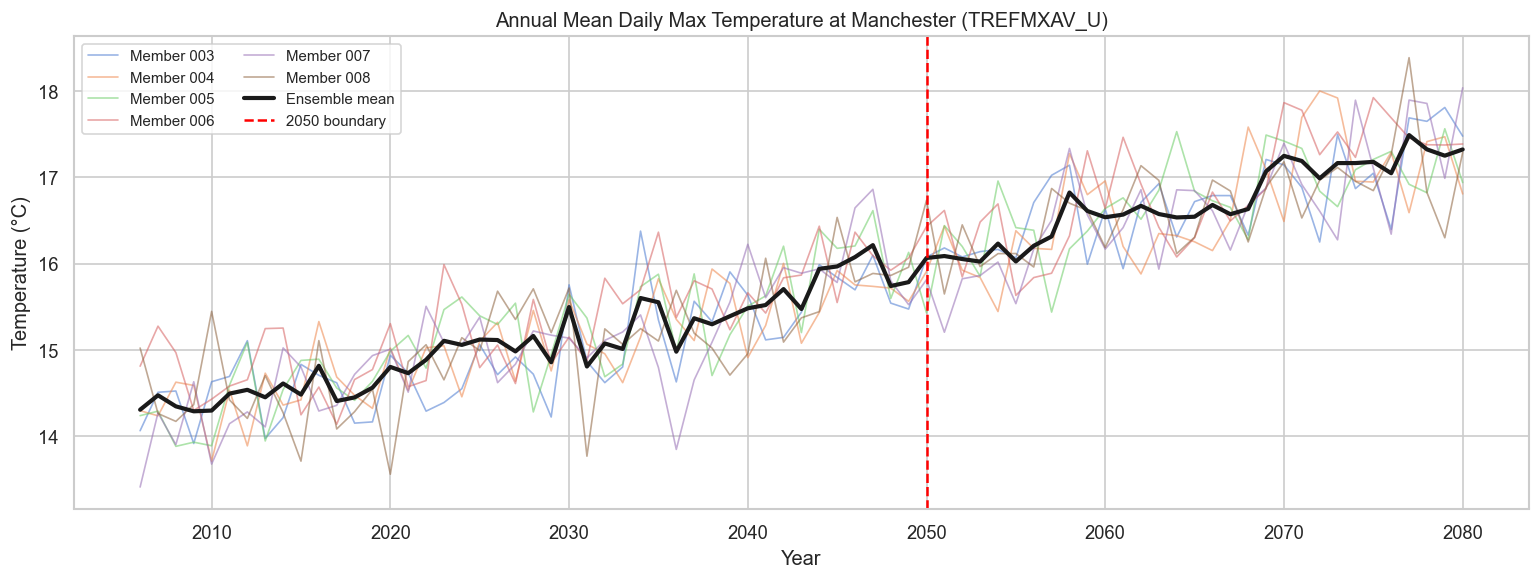

In [8]:
# ============================================================
# Temperature EDA: Annual Mean Time Series
# ============================================================
# Purpose:
#   Plot annual mean Tmax for each ensemble member and the ensemble mean.
# Key variables:
#   - `ann`: annual mean Tmax by member and year
#   - `ens_mean`: average across members
# Why this step:
#   - annual aggregation reduces day-to-day noise
#   - showing both members and ensemble mean separates signal from variability

annual = (
    data.groupby(["member", "year"])["TREFMXAV_U_C"]
    .mean()
    .reset_index(name="ann_mean")
)
ens_mean = annual.groupby("year")["ann_mean"].mean()

fig, ax = plt.subplots(figsize=(13, 5))
for mid, grp in annual.groupby("member"):
    ax.plot(grp["year"], grp["ann_mean"], lw=1.0, alpha=0.55, label=f"Member {mid}")
ax.plot(ens_mean.index, ens_mean.values, "k-", lw=2.5, label="Ensemble mean")
ax.axvline(2050, color="red", ls="--", lw=1.5, label="2050 boundary")
ax.set_title("Annual Mean Daily Max Temperature at Manchester (TREFMXAV_U)")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig("eda_01_annual_timeseries.png", dpi=150)
plt.show()


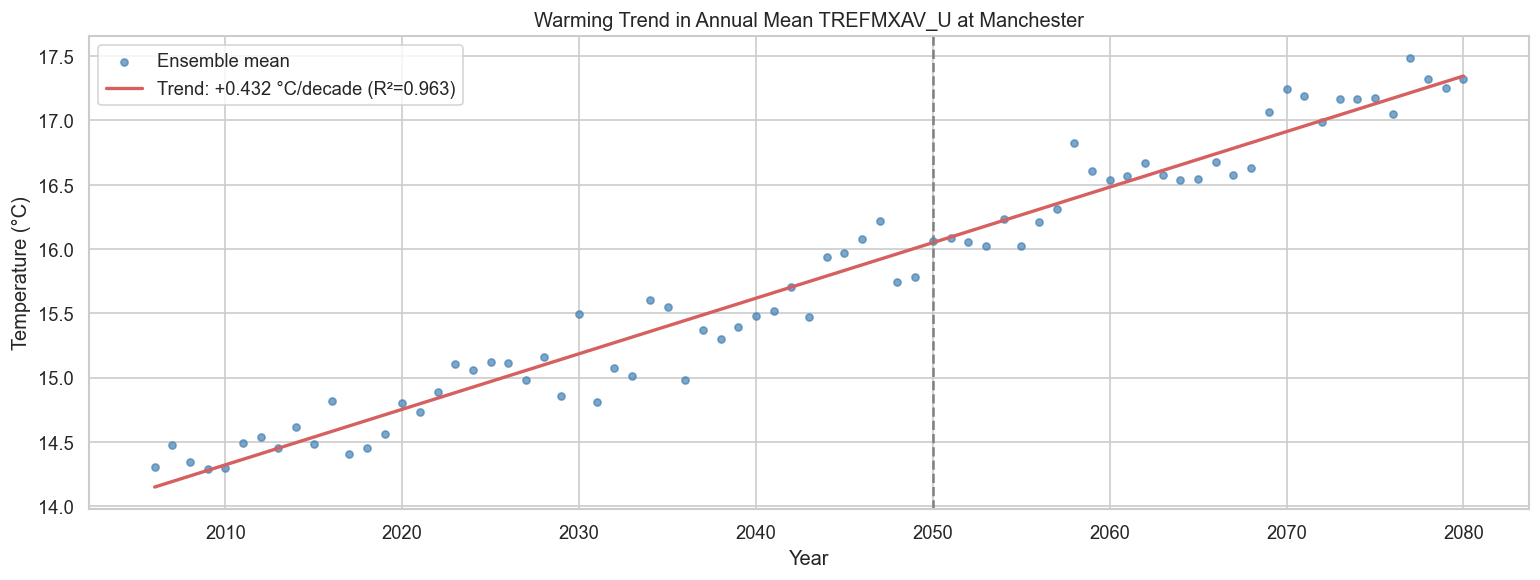

Trend: 0.0432 °C/year  (0.432 °C/decade)
Estimated warming 2006 to 2080: 3.20 °C


In [9]:
# ============================================================
# Temperature EDA: Linear Warming Trend
# ============================================================
# Purpose:
#   Fit a linear trend through annual mean Tmax to quantify long-term warming.
# Key variables:
#   - `slope`, `intercept`: fitted trend parameters
#   - `r`: correlation strength of the trend
# Why this step:
#   - a trend line turns the visual increase into a quantitative rate
#   - this supports the final warming conclusion with a simple summary statistic

slope, intercept, r, p, se = stats.linregress(ens_mean.index, ens_mean.values)
trend = slope * ens_mean.index + intercept

fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(ens_mean.index, ens_mean.values, s=18, color="steelblue", alpha=0.7, label="Ensemble mean")
ax.plot(
    ens_mean.index,
    trend,
    "r-",
    lw=2,
    label=f"Trend: {slope*10:+.3f} °C/decade (R²={r**2:.3f})"
)
ax.axvline(2050, color="grey", ls="--", lw=1.5)
ax.set_title("Warming Trend in Annual Mean TREFMXAV_U at Manchester")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.legend()
plt.tight_layout()
plt.savefig("eda_02_warming_trend.png", dpi=150)
plt.show()

print(f"Trend: {slope:.4f} °C/year  ({slope*10:.3f} °C/decade)")
print(f"Estimated warming 2006 to 2080: {slope*(2080-2006):.2f} °C")


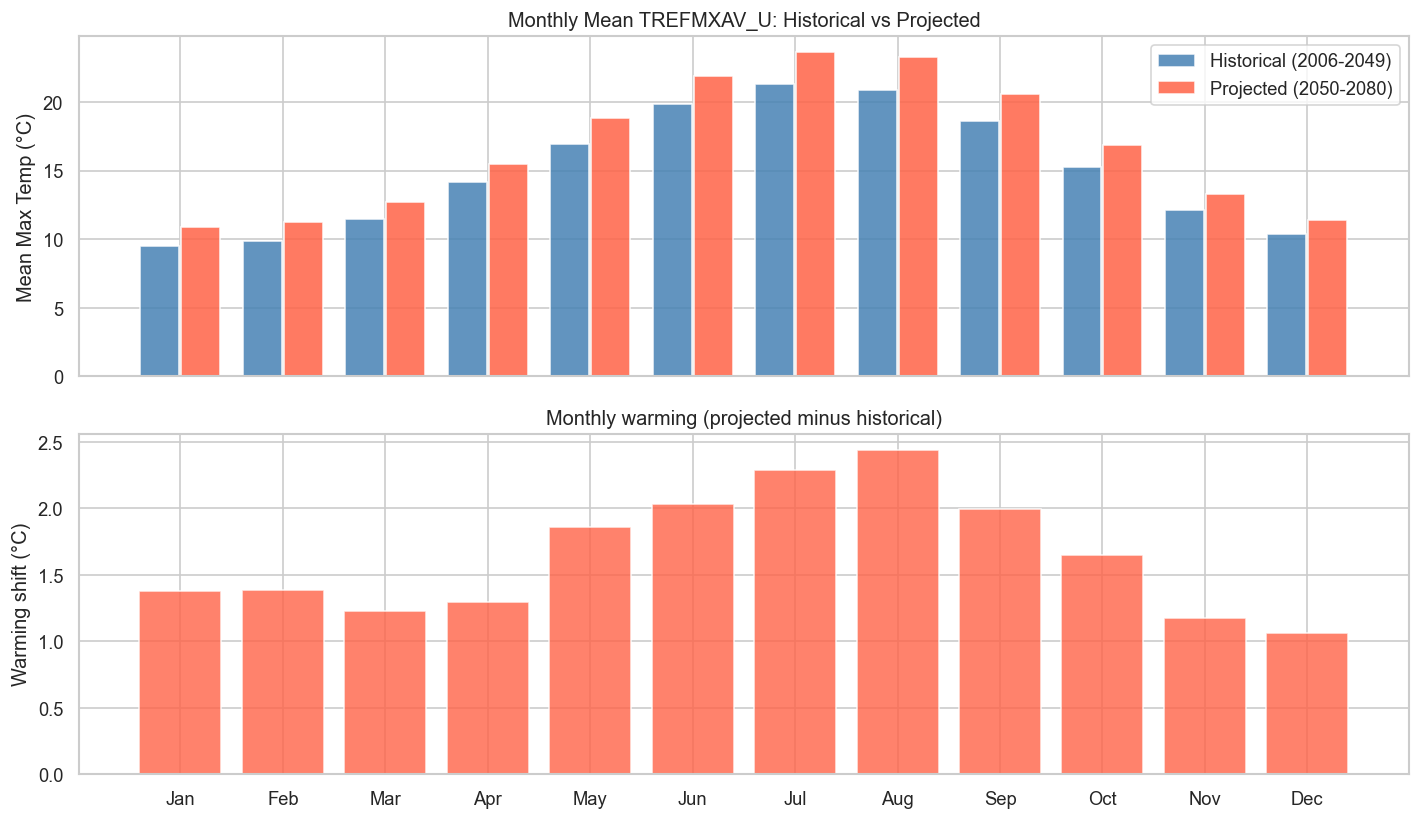


Monthly warming shifts:
  Jan: +1.38 °C
  Feb: +1.39 °C
  Mar: +1.23 °C
  Apr: +1.30 °C
  May: +1.86 °C
  Jun: +2.03 °C
  Jul: +2.29 °C
  Aug: +2.44 °C
  Sep: +2.00 °C
  Oct: +1.65 °C
  Nov: +1.17 °C
  Dec: +1.06 °C


In [10]:
# ============================================================
# Temperature EDA: Seasonal Cycle
# ============================================================
# Purpose:
#   Compare monthly mean Tmax between the historical and projected periods.
# Key variables:
#   - `monthly_hist`, `monthly_proj`: monthly means
#   - `monthly_shift`: projected minus historical change
# Why this step:
#   - seasonal averages show whether warming is uniform or concentrated in certain months
#   - this is how we identify stronger summer warming

MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

hist = data[data["year"] <= 2049]
proj = data[data["year"] >= 2050]

hist_monthly = hist.groupby("month")["TREFMXAV_U_C"].mean()
proj_monthly = proj.groupby("month")["TREFMXAV_U_C"].mean()
shift = proj_monthly - hist_monthly

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

x = np.arange(1, 13)
axes[0].bar(x - 0.2, hist_monthly, 0.38, label="Historical (2006-2049)", color="steelblue", alpha=0.85)
axes[0].bar(x + 0.2, proj_monthly, 0.38, label="Projected (2050-2080)", color="tomato", alpha=0.85)
axes[0].set_ylabel("Mean Max Temp (°C)")
axes[0].set_title("Monthly Mean TREFMXAV_U: Historical vs Projected")
axes[0].legend()

axes[1].bar(x, shift, color="tomato", alpha=0.8)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("Warming shift (°C)")
axes[1].set_title("Monthly warming (projected minus historical)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(MONTH_NAMES)

plt.tight_layout()
plt.savefig("eda_03_seasonal_cycle.png", dpi=150)
plt.show()

print("\nMonthly warming shifts:")
for m, name in enumerate(MONTH_NAMES, 1):
    print(f"  {name}: {shift[m]:+.2f} °C")


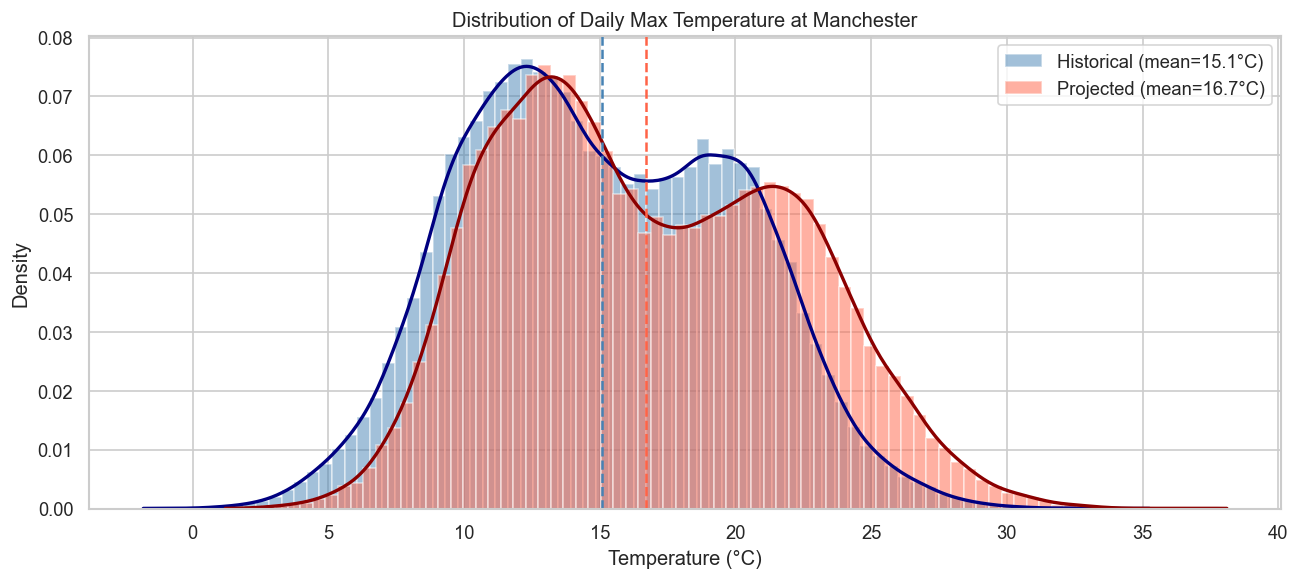

Mean shift: +1.65°C
Welch t-test: t=-62.86, p=0.00e+00  (significant: True)


In [11]:
# ============================================================
# Temperature EDA: Distribution Shift
# ============================================================
# Purpose:
#   Compare the full Tmax distribution between the historical and projected periods.
# Key variables:
#   - `hist_vals`, `proj_vals`: daily Tmax samples
#   - `t_stat`, `p_val`: Welch test results
# Why this step:
#   - a mean change alone cannot show whether the whole climate state has shifted
#   - distribution plots reveal whether higher values become generally more common

hist_vals = hist["TREFMXAV_U_C"].dropna()
proj_vals = proj["TREFMXAV_U_C"].dropna()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(
    hist_vals, bins=80, alpha=0.5, color="steelblue", density=True,
    label=f"Historical (mean={hist_vals.mean():.1f}°C)"
)
ax.hist(
    proj_vals, bins=80, alpha=0.5, color="tomato", density=True,
    label=f"Projected (mean={proj_vals.mean():.1f}°C)"
)

for vals, col in [(hist_vals, "navy"), (proj_vals, "darkred")]:
    kde = gaussian_kde(vals)
    xs = np.linspace(vals.min(), vals.max(), 400)
    ax.plot(xs, kde(xs), color=col, lw=2)

ax.axvline(hist_vals.mean(), color="steelblue", ls="--", lw=1.5)
ax.axvline(proj_vals.mean(), color="tomato", ls="--", lw=1.5)
ax.set_title("Distribution of Daily Max Temperature at Manchester")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("eda_04_distribution.png", dpi=150)
plt.show()

t_stat, p_val = stats.ttest_ind(hist_vals, proj_vals, equal_var=False)
print(f"Mean shift: {proj_vals.mean() - hist_vals.mean():+.2f}°C")
print(f"Welch t-test: t={t_stat:.2f}, p={p_val:.2e}  (significant: {p_val < 0.05})")


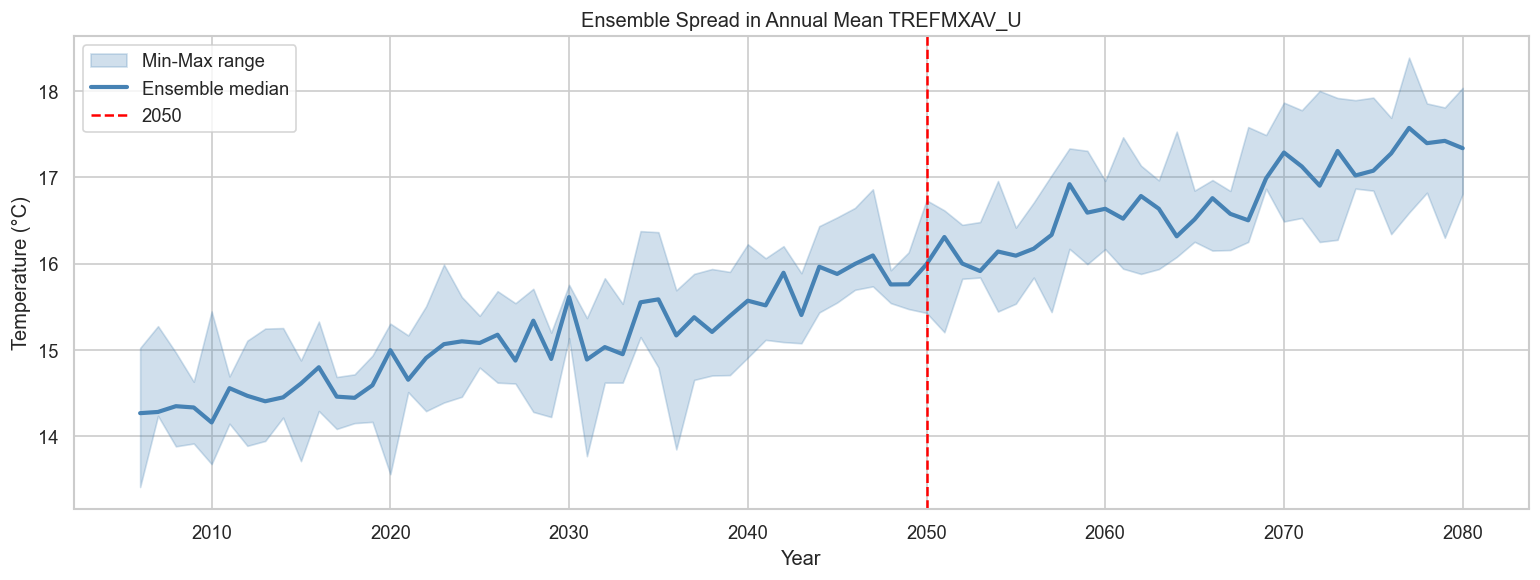

Spread in projected period: mean 1.17°C, max 1.79°C


In [12]:
# ============================================================
# Temperature EDA: Ensemble Spread
# ============================================================
# Purpose:
#   Show the range across ensemble members to separate forced change from internal variability.
# Key variables:
#   - `ann_pivot`: annual means by member
#   - `ann_min`, `ann_max`, `ann_med`: spread summaries
# Why this step:
#   - ensemble spread is a simple uncertainty diagnostic
#   - it shows whether the signal is robust across members

ann_pivot = annual.pivot(index="year", columns="member", values="ann_mean")
ann_min = ann_pivot.min(axis=1)
ann_max = ann_pivot.max(axis=1)
ann_med = ann_pivot.median(axis=1)

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(ann_pivot.index, ann_min, ann_max, alpha=0.25, color="steelblue", label="Min-Max range")
ax.plot(ann_pivot.index, ann_med, color="steelblue", lw=2.5, label="Ensemble median")
ax.axvline(2050, color="red", ls="--", lw=1.5, label="2050")
ax.set_title("Ensemble Spread in Annual Mean TREFMXAV_U")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.legend()
plt.tight_layout()
plt.savefig("eda_05_ensemble_spread.png", dpi=150)
plt.show()

spread_proj = ann_max[ann_max.index >= 2050] - ann_min[ann_min.index >= 2050]
print(f"Spread in projected period: mean {spread_proj.mean():.2f}°C, max {spread_proj.max():.2f}°C")


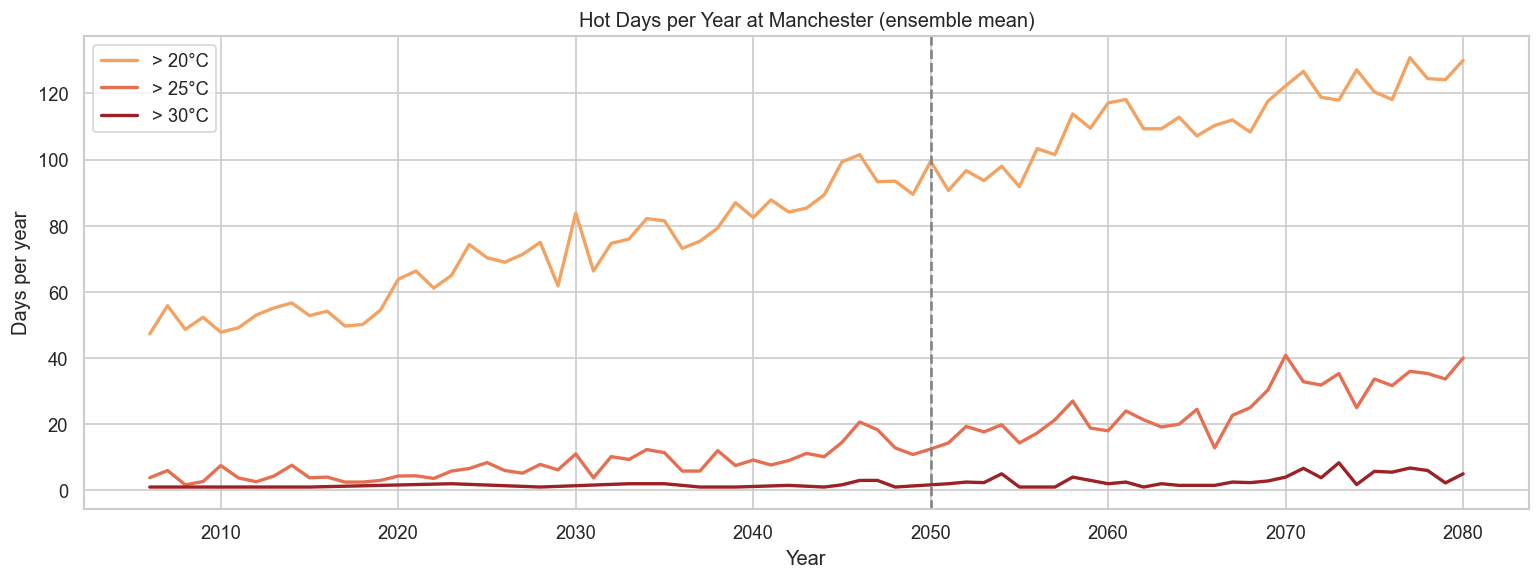


Hot days per year (ensemble mean):
  > 20°C:  hist=70.3/yr  proj=112.3/yr  change=+42.1
  > 25°C:  hist=7.7/yr  proj=25.0/yr  change=+17.3
  > 30°C:  hist=1.9/yr  proj=3.6/yr  change=+1.7


In [13]:
# ============================================================
# Temperature EDA: Hot-Day Frequency
# ============================================================
# Purpose:
#   Count how often warm thresholds are exceeded each year.
# Key variables:
#   - `thresholds`: hot-day cutoffs such as 20, 25, and 30 C
#   - `by_year`: annual exceedance frequency
# Why this step:
#   - threshold counts translate warming into an easier-to-interpret impact metric
#   - this links climate change to the frequency of hot conditions

thresholds = [20, 25, 30]
colors = ["#f4a261", "#e76f51", "#9b2226"]

fig, ax = plt.subplots(figsize=(13, 5))
for thresh, col in zip(thresholds, colors):
    by_year = (
        data[data["TREFMXAV_U_C"] > thresh]
        .groupby(["member", "year"])
        .size()
        .groupby("year")
        .mean()
    )
    ax.plot(by_year.index, by_year.values, color=col, lw=2, label=f"> {thresh}°C")

ax.axvline(2050, color="grey", ls="--", lw=1.5)
ax.set_title("Hot Days per Year at Manchester (ensemble mean)")
ax.set_xlabel("Year")
ax.set_ylabel("Days per year")
ax.legend()
plt.tight_layout()
plt.savefig("eda_06_hot_days.png", dpi=150)
plt.show()

print("\nHot days per year (ensemble mean):")
for thresh in thresholds:
    h = (
        data[(data["year"] <= 2049) & (data["TREFMXAV_U_C"] > thresh)]
        .groupby(["member", "year"])
        .size()
        .mean()
    )
    p = (
        data[(data["year"] >= 2050) & (data["TREFMXAV_U_C"] > thresh)]
        .groupby(["member", "year"])
        .size()
        .mean()
    )
    print(f"  > {thresh}°C:  hist={h:.1f}/yr  proj={p:.1f}/yr  change={p-h:+.1f}")


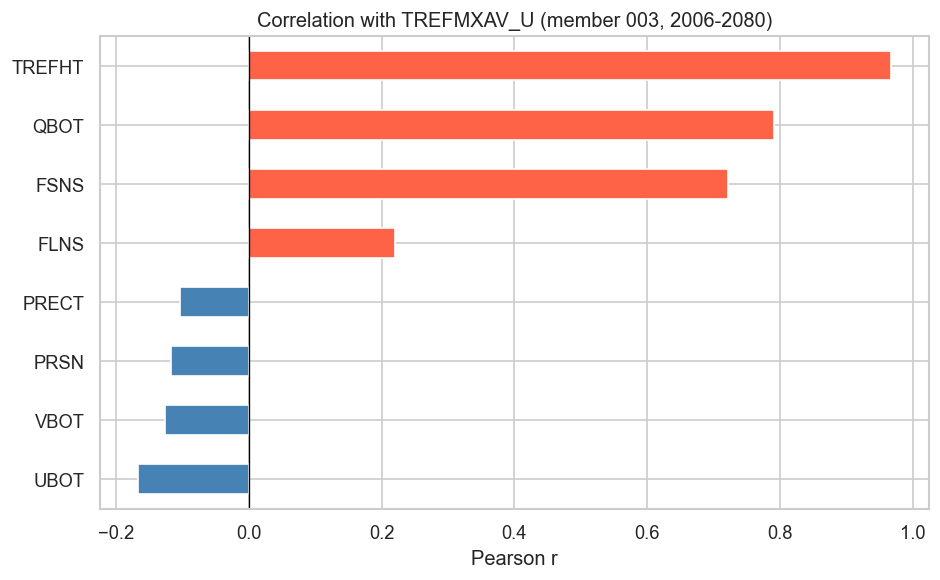


Correlations with TREFMXAV_U:
  TREFHT  : r = +0.9676
  QBOT    : r = +0.7916
  FSNS    : r = +0.7213
  FLNS    : r = +0.2197
  UBOT    : r = -0.1674
  VBOT    : r = -0.1264
  PRSN    : r = -0.1170
  PRECT   : r = -0.1038


In [14]:
# ============================================================
# Temperature EDA: Correlations With Other Variables
# ============================================================
# Purpose:
#   Measure how strongly Tmax co-varies with the other climate variables.
# Key variables:
#   - `corr_vars`: variables compared with Tmax
#   - `corr_df`: sorted correlation values
# Why this step:
#   - this helps interpret the climate relationships before modelling
#   - it also foreshadows which variables may become useful ML predictors

VARS = ["TREFHT", "FSNS", "QBOT", "FLNS", "UBOT", "VBOT", "PRECT", "PRSN"]
member0 = data[data["member"] == MEMBER_IDS[0]].copy()

corrs = {}
for v in VARS:
    if v in member0.columns:
        r = np.corrcoef(member0["TREFMXAV_U_C"], member0[v])[0, 1]
        corrs[v] = round(r, 4)

if len(corrs) > 0:
    corr_df = pd.Series(corrs).sort_values()

    fig, ax = plt.subplots(figsize=(8, 5))
    colors_bar = ["tomato" if v > 0 else "steelblue" for v in corr_df.values]
    corr_df.plot(kind="barh", ax=ax, color=colors_bar)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(f"Correlation with TREFMXAV_U (member {MEMBER_IDS[0]}, 2006-2080)")
    ax.set_xlabel("Pearson r")
    plt.tight_layout()
    plt.savefig("eda_07_correlations.png", dpi=150)
    plt.show()

    print("\nCorrelations with TREFMXAV_U:")
    for v, r in sorted(corrs.items(), key=lambda x: -abs(x[1])):
        print(f"  {v:8s}: r = {r:+.4f}")
else:
    print("\nNo correlation variables found in dataset.")


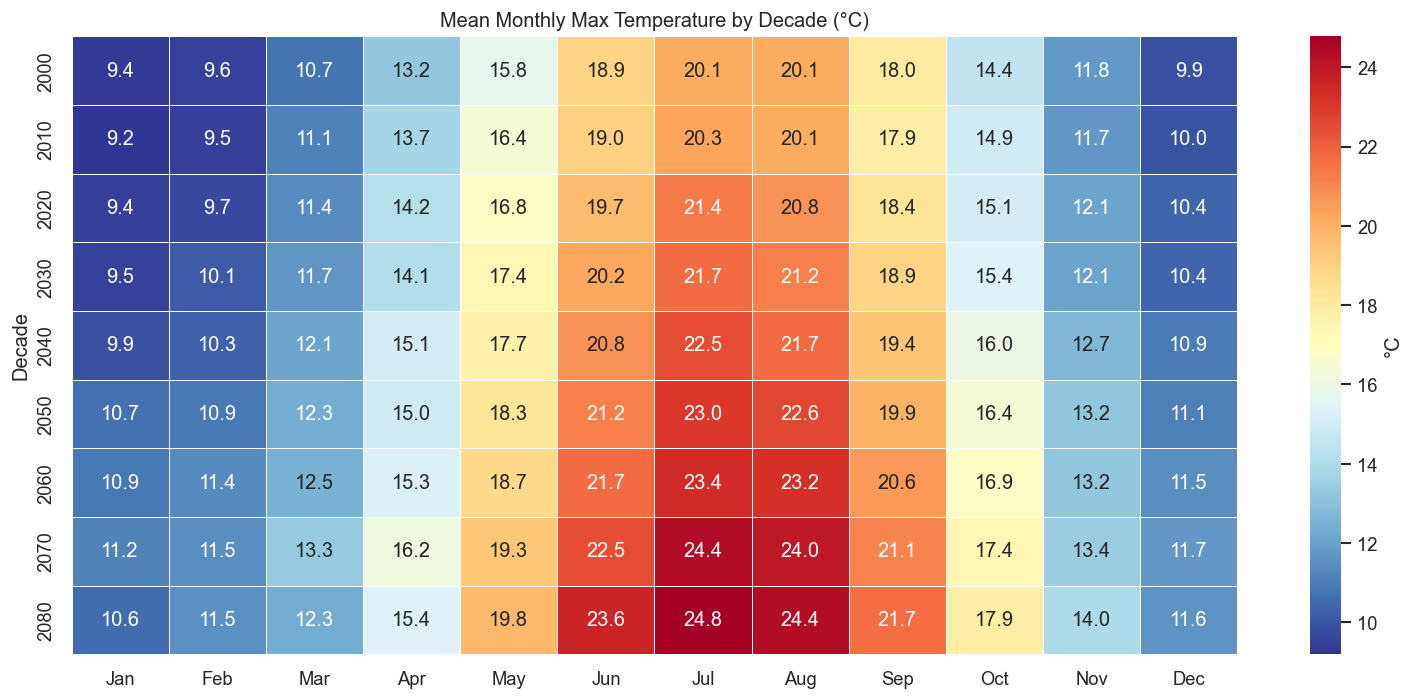


EDA done.


In [15]:
# ============================================================
# Temperature EDA: Decade-by-Month Heatmap
# ============================================================
# Purpose:
#   Summarise how average monthly Tmax changes across decades.
# Key variables:
#   - `hmap`: decade-by-month table of mean Tmax
# Why this step:
#   - the heatmap compresses the long record into one visual summary
#   - it helps show how warming accumulates over time and across seasons

data["decade"] = (data["year"] // 10) * 10
hmap = data.groupby(["decade", "month"])["TREFMXAV_U_C"].mean().unstack("month")
hmap.columns = MONTH_NAMES

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    hmap,
    annot=True,
    fmt=".1f",
    cmap="RdYlBu_r",
    ax=ax,
    linewidths=0.4,
    cbar_kws={"label": "°C"}
)
ax.set_title("Mean Monthly Max Temperature by Decade (°C)")
ax.set_ylabel("Decade")
plt.tight_layout()
plt.savefig("eda_08_decade_heatmap.png", dpi=150)
plt.show()

print("\nEDA done.")


In [16]:
# ============================================================
# Temperature ML: Feature Engineering
# ============================================================
# Purpose:
#   Create cyclical seasonal features and a normalised year trend signal for the Tmax model.
# Key variables:
#   - `sin_doy`, `cos_doy`: cyclical day-of-year encoding
#   - `year_norm`: scaled long-term trend feature
#   - `FEATURE_COLS`: final predictor list
# Why this step:
#   - cyclical encoding keeps late December close to early January
#   - the normalised year gives the model a simple representation of long-term change

#
# sin/cos encoding of day-of-year so Dec 31 and Jan 1 are close together.
# year_norm goes from 0 (2006) to 1 (2080) to give the model a trend signal.

data["sin_doy"] = np.sin(2 * np.pi * data["doy"] / 365.25)
data["cos_doy"] = np.cos(2 * np.pi * data["doy"] / 365.25)

YEAR_MIN = data["year"].min()
YEAR_MAX = data["year"].max()
data["year_norm"] = (data["year"] - YEAR_MIN) / (YEAR_MAX - YEAR_MIN)

FEATURE_COLS = FEATURE_VARS + ["sin_doy", "cos_doy", "year_norm"]

print(f"{len(FEATURE_COLS)} features: {FEATURE_COLS}")


11 features: ['TREFHT', 'FSNS', 'QBOT', 'FLNS', 'UBOT', 'VBOT', 'PRECT', 'PRSN', 'sin_doy', 'cos_doy', 'year_norm']


In [17]:
# ============================================================
# Temperature ML: Train-Test Split
# ============================================================
# Purpose:
#   Split the data into historical training years and future testing years.
# Key variables:
#   - `train`, `test`: historical and future subsets
#   - `X_train`, `X_test`: predictor matrices
#   - `y_train`, `y_test`: Tmax target arrays
# Why this step:
#   - a temporal split matches the scientific question of learning from the past and testing on the future
#   - it avoids the optimistic bias of random mixing across years

train = data[data["year"] <= 2049].copy()
test = data[data["year"] >= 2050].copy()

X_train = train[FEATURE_COLS].values
y_train = train["TREFMXAV_U_C"].values

X_test = test[FEATURE_COLS].values
y_test = test["TREFMXAV_U_C"].values

print(f"\nTrain: {len(X_train):,} samples ({train['year'].min()}-{train['year'].max()})")
print(f"Test:  {len(X_test):,} samples ({test['year'].min()}-{test['year'].max()})")

# Ridge needs scaled features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)



Train: 96,354 samples (2006-2049)
Test:  67,890 samples (2050-2080)


In [18]:
# ============================================================
# Temperature ML: Train Candidate Models
# ============================================================
# Purpose:
#   Fit three regression models and compare their future-period performance.
# Key variables:
#   - `models`: Ridge, Random Forest, and Gradient Boosting
#   - `results`: prediction and metric store for each model
# Why this step:
#   - using a linear baseline plus two nonlinear methods shows whether extra complexity helps
#   - comparing several models is more convincing than reporting one model only

models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    ),
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    Xtr = X_train_s if name == "Ridge Regression" else X_train
    Xte = X_test_s if name == "Ridge Regression" else X_test

    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results[name] = {
        "model": model,
        "preds": preds,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    print(f"  MAE = {mae:.3f}°C   RMSE = {rmse:.3f}°C   R² = {r2:.4f}")

best_name = max(results, key=lambda k: results[k]["R2"])
best_preds = results[best_name]["preds"]

print(f"\nBest: {best_name} (R²={results[best_name]['R2']:.4f})")



Training Ridge Regression...
  MAE = 0.602°C   RMSE = 0.788°C   R² = 0.9788

Training Random Forest...
  MAE = 0.526°C   RMSE = 0.698°C   R² = 0.9833

Training Gradient Boosting...
  MAE = 0.504°C   RMSE = 0.669°C   R² = 0.9847

Best: Gradient Boosting (R²=0.9847)


In [19]:
# ============================================================
# Temperature ML: Metrics Table
# ============================================================
# Purpose:
#   Summarise MAE, RMSE, and R² for all Tmax models.
# Key variables:
#   - `metrics_df`: compact performance comparison table
# Why this step:
#   - placing metrics in one table makes model ranking transparent
#   - MAE, RMSE, and R² each capture a slightly different aspect of performance

metrics_df = pd.DataFrame(
    {
        k: {
            "MAE (°C)": v["MAE"],
            "RMSE (°C)": v["RMSE"],
            "R²": v["R2"]
        }
        for k, v in results.items()
    }
).T.round(4)

print("\nModel performance on 2050-2080:")
print(metrics_df.to_string())
metrics_df.to_csv("model_metrics.csv")



Model performance on 2050-2080:
                   MAE (°C)  RMSE (°C)      R²
Ridge Regression     0.6016     0.7878  0.9788
Random Forest        0.5264     0.6977  0.9833
Gradient Boosting    0.5043     0.6693  0.9847


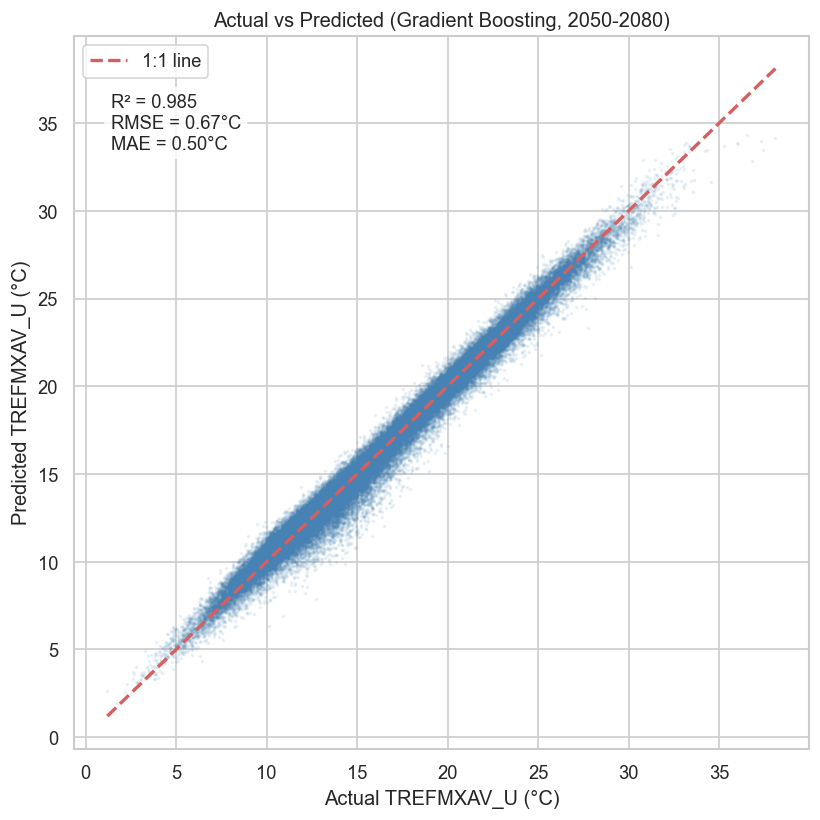

In [20]:
# ============================================================
# Temperature ML: Actual Vs Predicted Scatter
# ============================================================
# Purpose:
#   Check whether the best Tmax model follows the one-to-one relationship on the future test period.
# Key variables:
#   - `best_name`: model selected by highest R²
#   - `best_preds`: predictions from the best model
# Why this step:
#   - scatter around the 1:1 line is an intuitive visual diagnostic
#   - this quickly reveals bias, spread, and extreme-value behaviour

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, best_preds, s=1.5, alpha=0.08, color="steelblue", rasterized=True)

lims = [
    min(y_test.min(), best_preds.min()),
    max(y_test.max(), best_preds.max())
]
ax.plot(lims, lims, "r--", lw=2, label="1:1 line")

ax.set_xlabel("Actual TREFMXAV_U (°C)")
ax.set_ylabel("Predicted TREFMXAV_U (°C)")
ax.set_title(f"Actual vs Predicted ({best_name}, 2050-2080)")
ax.legend()

ax.text(
    0.05, 0.92,
    f"R² = {results[best_name]['R2']:.3f}\n"
    f"RMSE = {results[best_name]['RMSE']:.2f}°C\n"
    f"MAE = {results[best_name]['MAE']:.2f}°C",
    transform=ax.transAxes,
    fontsize=11,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.savefig("ml_01_scatter.png", dpi=150)
plt.show()


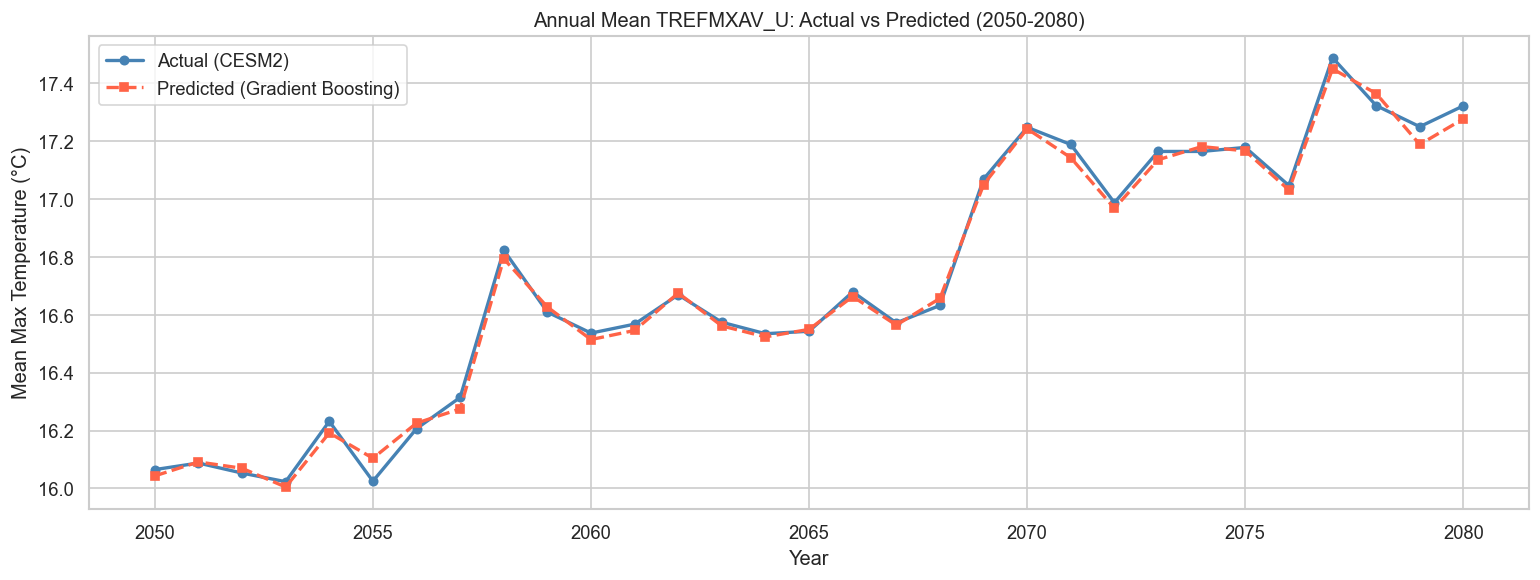

In [21]:
# ============================================================
# Temperature ML: Annual Mean Comparison
# ============================================================
# Purpose:
#   Compare annual mean observed and predicted Tmax across the future period.
# Key variables:
#   - `ann_obs`, `ann_pred`: annual means of actual and predicted Tmax
# Why this step:
#   - annual aggregation checks whether the model captures long-term future evolution
#   - it complements the daily scatter with a time-series view

test_df = test.copy()
test_df["predicted_C"] = best_preds

ann_obs = test_df.groupby("year")["TREFMXAV_U_C"].mean()
ann_pred = test_df.groupby("year")["predicted_C"].mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(
    ann_obs.index, ann_obs.values,
    "o-",
    color="steelblue",
    lw=2,
    ms=5,
    label="Actual (CESM2)"
)
ax.plot(
    ann_pred.index, ann_pred.values,
    "s--",
    color="tomato",
    lw=2,
    ms=5,
    label=f"Predicted ({best_name})"
)

ax.set_title("Annual Mean TREFMXAV_U: Actual vs Predicted (2050-2080)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Max Temperature (°C)")
ax.legend()

plt.tight_layout()
plt.savefig("ml_02_annual_comparison.png", dpi=150)
plt.show()


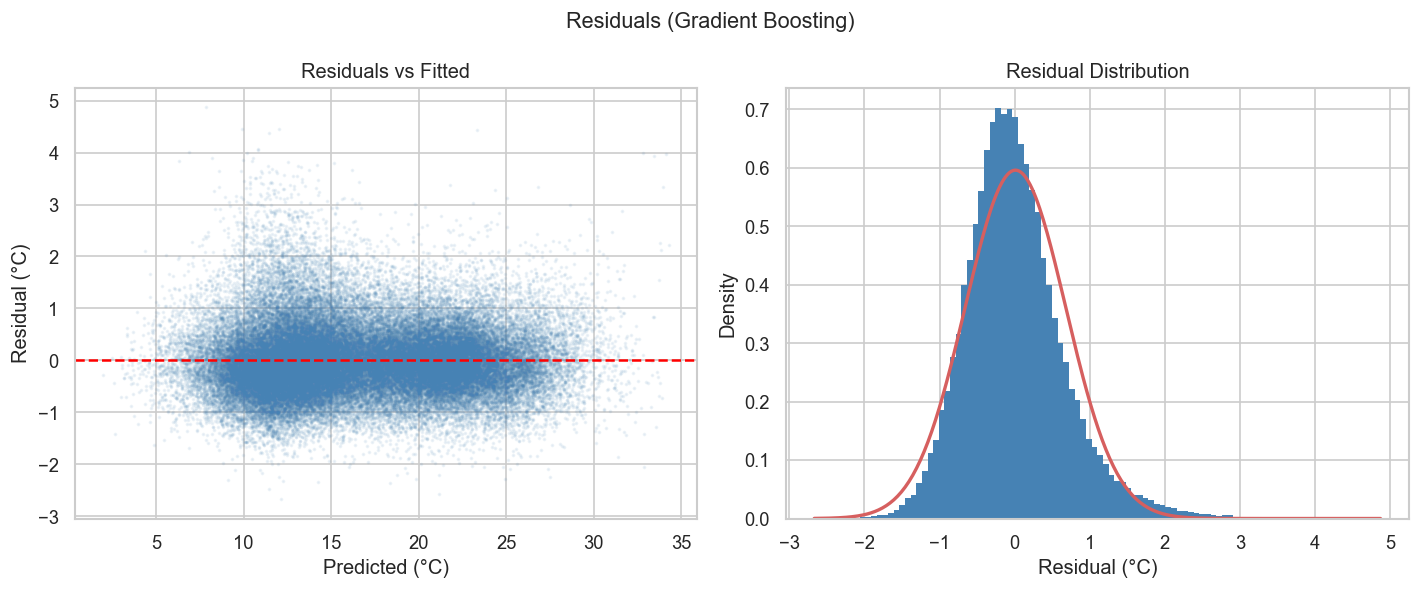

Residual mean: 0.0097°C
Residual std:  0.6692°C


In [22]:
# ============================================================
# Temperature ML: Residual Analysis
# ============================================================
# Purpose:
#   Inspect the distribution and structure of errors from the best Tmax model.
# Key variables:
#   - `residuals`: actual minus predicted values
# Why this step:
#   - residual plots help check whether errors are centred near zero and roughly pattern-free
#   - this is a standard sanity check after fitting a regression model

residuals = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(best_preds, residuals, s=1.5, alpha=0.08, color="steelblue", rasterized=True)
axes[0].axhline(0, color="red", ls="--", lw=1.5)
axes[0].set_xlabel("Predicted (°C)")
axes[0].set_ylabel("Residual (°C)")
axes[0].set_title("Residuals vs Fitted")

axes[1].hist(residuals, bins=100, color="steelblue", density=True, edgecolor="none")
xs = np.linspace(residuals.min(), residuals.max(), 300)
axes[1].plot(xs, stats.norm.pdf(xs, residuals.mean(), residuals.std()), "r-", lw=2)
axes[1].set_xlabel("Residual (°C)")
axes[1].set_ylabel("Density")
axes[1].set_title("Residual Distribution")

plt.suptitle(f"Residuals ({best_name})", fontsize=13)
plt.tight_layout()
plt.savefig("ml_03_residuals.png", dpi=150)
plt.show()

print(f"Residual mean: {residuals.mean():.4f}°C")
print(f"Residual std:  {residuals.std():.4f}°C")


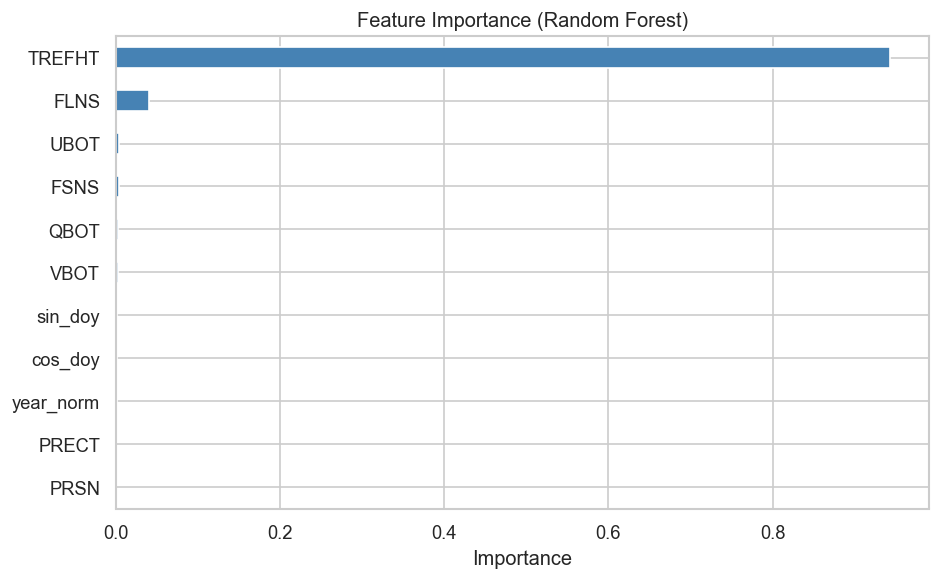

In [23]:
# ============================================================
# Temperature ML: Feature Importance
# ============================================================
# Purpose:
#   Use Random Forest importance scores to show which inputs matter most for Tmax prediction.
# Key variables:
#   - `rf_model`: fitted random forest
#   - `fi`: feature-importance series
# Why this step:
#   - importance values provide an interpretable ranking of predictors
#   - they help connect the ML model back to the earlier correlation analysis

rf_model = results["Random Forest"]["model"]
fi = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
fi.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Importance (Random Forest)")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.savefig("ml_04_feature_importance.png", dpi=150)
plt.show()


In [24]:
# ============================================================
# Temperature ML: Save Predictions
# ============================================================
# Purpose:
#   Write future-period Tmax predictions to CSV for later checking and plotting.
# Key variables:
#   - `output`: saved table of actual and predicted Tmax values
# Why this step:
#   - saving model outputs makes the workflow reproducible
#   - the CSV can be reused without rerunning the whole model

output = test_df[["time", "member", "year", "month", "TREFMXAV_U_C", "predicted_C"]].copy()
output.to_csv("predictions_2050_2080.csv", index=False)
print("\nSaved predictions to predictions_2050_2080.csv")



Saved predictions to predictions_2050_2080.csv


In [25]:
# ============================================================
# QBOT EDA: Summary Statistics
# ============================================================
# Purpose:
#   Summarise specific humidity in g/kg and split it into historical and projected periods.
# Key variables:
#   - `QBOT_gkg`: QBOT converted from kg/kg to g/kg
#   - `qbot_hist`, `qbot_proj`: historical and projected subsets
# Why this step:
#   - g/kg is much easier to interpret than raw kg/kg
#   - the same period split is reused across every QBOT diagnostic

if "QBOT" not in data.columns:
    raise ValueError("Missing required variable for QBOT EDA: QBOT")

if "QBOT_gkg" not in data.columns:
    data["QBOT_gkg"] = data["QBOT"] * 1000.0

QBOT_MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

qbot_hist = data[data["year"] <= 2049].copy()
qbot_proj = data[data["year"] >= 2050].copy()

print("\nQBOT summary (g/kg):\n")

print("Overall:")
print(data["QBOT_gkg"].describe().round(3))

print("\nHistorical (2006-2049) vs Projected (2050-2080):")
qbot_summary = (
    data.assign(period=data["year"].map(lambda y: "2006-2049" if y <= 2049 else "2050-2080"))
    .groupby("period")["QBOT_gkg"]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)
print(qbot_summary)

print("\nPer-member means in the projected period:")
print(
    data[data["year"] >= 2050]
    .groupby("member")["QBOT_gkg"]
    .mean()
    .round(3)
)



QBOT summary (g/kg):

Overall:
count    164244.000
mean          6.545
std           2.123
min           1.555
25%           4.879
50%           6.246
75%           7.988
max          18.279
Name: QBOT_gkg, dtype: float64

Historical (2006-2049) vs Projected (2050-2080):
            mean    std    min        max
period                                   
2006-2049  6.300  2.005  1.555  16.483000
2050-2080  6.894  2.234  1.807  18.278999

Per-member means in the projected period:
member
003    6.860
004    6.932
005    6.903
006    6.970
007    6.860
008    6.837
Name: QBOT_gkg, dtype: float32


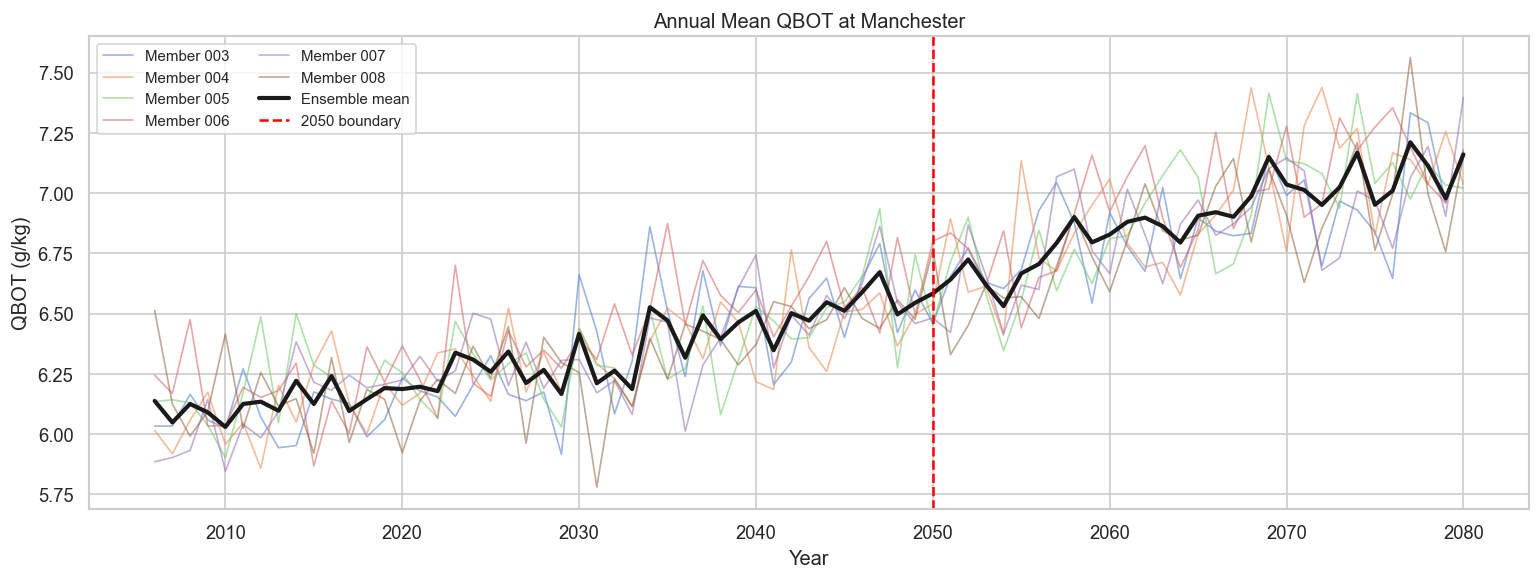

In [26]:
# ============================================================
# QBOT EDA: Annual Mean Time Series
# ============================================================
# Purpose:
#   Plot annual mean QBOT for each ensemble member and the ensemble mean.
# Key variables:
#   - `qbot_annual`: annual QBOT by member and year
#   - `qbot_ens_mean`: ensemble-average annual QBOT
# Why this step:
#   - annual means make the long-term moistening signal easier to see
#   - member lines plus ensemble mean show both variability and common signal

qbot_annual = (
    data.groupby(["member", "year"])["QBOT_gkg"]
    .mean()
    .reset_index(name="ann_mean")
)
qbot_ens_mean = qbot_annual.groupby("year")["ann_mean"].mean()

fig, ax = plt.subplots(figsize=(13, 5))
for mid, grp in qbot_annual.groupby("member"):
    ax.plot(grp["year"], grp["ann_mean"], lw=1.0, alpha=0.55, label=f"Member {mid}")
ax.plot(qbot_ens_mean.index, qbot_ens_mean.values, "k-", lw=2.5, label="Ensemble mean")
ax.axvline(2050, color="red", ls="--", lw=1.5, label="2050 boundary")
ax.set_title("Annual Mean QBOT at Manchester")
ax.set_xlabel("Year")
ax.set_ylabel("QBOT (g/kg)")
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig("qbot_01_annual_timeseries.png", dpi=150)
plt.show()


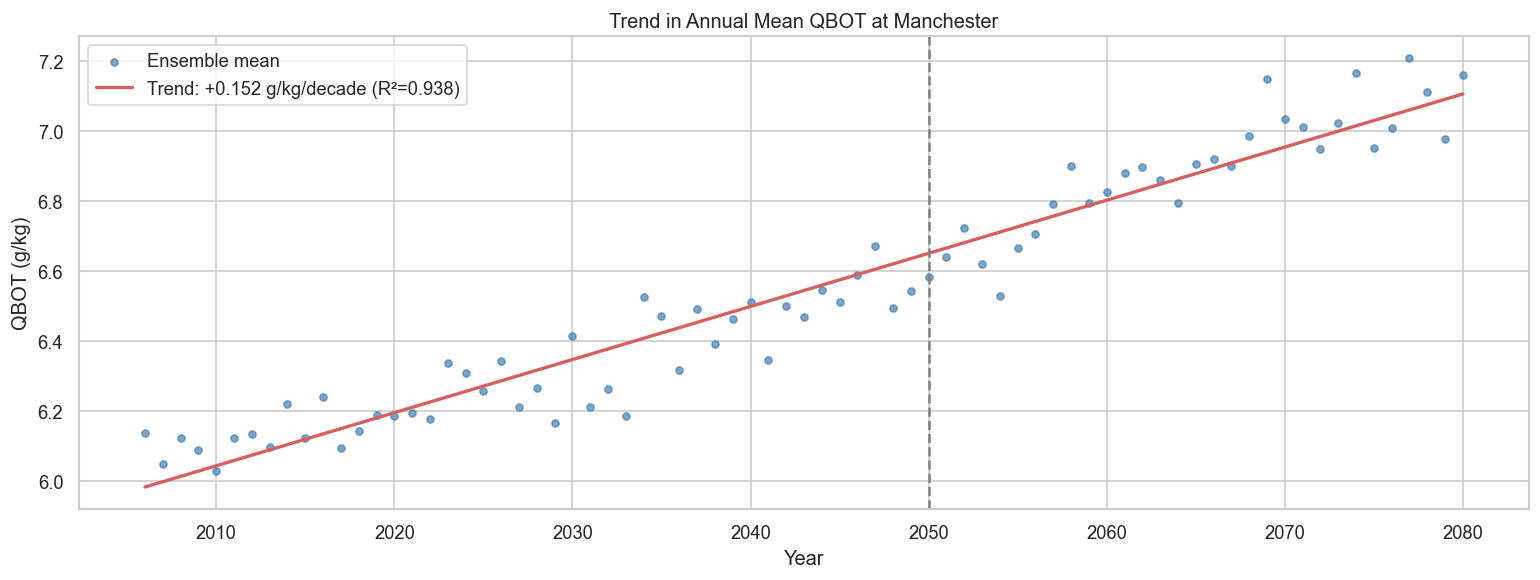

Trend: 0.0152 g/kg/year  (0.152 g/kg/decade)
Estimated change 2006 to 2080: 1.123 g/kg


In [27]:
# ============================================================
# QBOT EDA: Linear Trend
# ============================================================
# Purpose:
#   Fit a linear trend through annual mean QBOT to quantify moistening.
# Key variables:
#   - `qbot_slope`, `qbot_intercept`: fitted trend parameters
#   - `qbot_r`: trend strength
# Why this step:
#   - a trend line converts a visual increase into a numerical rate
#   - this is the clearest single summary of long-term moistening

qbot_slope, qbot_intercept, qbot_r, qbot_p, qbot_se = stats.linregress(
    qbot_ens_mean.index, qbot_ens_mean.values
)
qbot_trend = qbot_slope * qbot_ens_mean.index + qbot_intercept

fig, ax = plt.subplots(figsize=(13, 5))
ax.scatter(qbot_ens_mean.index, qbot_ens_mean.values, s=18, color="steelblue", alpha=0.7, label="Ensemble mean")
ax.plot(
    qbot_ens_mean.index,
    qbot_trend,
    "r-",
    lw=2,
    label=f"Trend: {qbot_slope*10:+.3f} g/kg/decade (R²={qbot_r**2:.3f})"
)
ax.axvline(2050, color="grey", ls="--", lw=1.5)
ax.set_title("Trend in Annual Mean QBOT at Manchester")
ax.set_xlabel("Year")
ax.set_ylabel("QBOT (g/kg)")
ax.legend()
plt.tight_layout()
plt.savefig("qbot_02_trend.png", dpi=150)
plt.show()

print(f"Trend: {qbot_slope:.4f} g/kg/year  ({qbot_slope*10:.3f} g/kg/decade)")
print(f"Estimated change 2006 to 2080: {qbot_slope*(2080-2006):.3f} g/kg")



QBOT mean moisture change:
  Historical mean: 6.300 g/kg
  Projected mean:  6.894 g/kg
  Absolute change: +0.594 g/kg
  Relative change: +9.42%


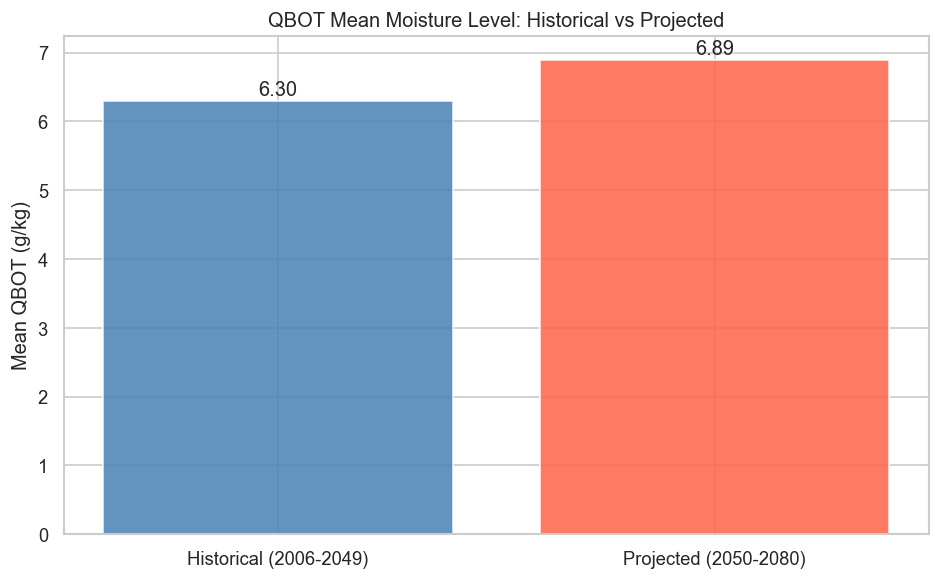

In [28]:
# ============================================================
# QBOT EDA: Mean Change
# ============================================================
# Purpose:
#   Directly compare average humidity between the historical and projected periods.
# Key variables:
#   - `qbot_hist_mean_gkg`, `qbot_proj_mean_gkg`: period means
#   - `qbot_abs_change_gkg`, `qbot_pct_change`: absolute and relative changes
# Why this step:
#   - a bar comparison is the quickest way to communicate how much wetter the future is
#   - reporting both absolute and relative change makes the result easier to interpret

qbot_hist_mean_gkg = qbot_hist["QBOT_gkg"].mean()
qbot_proj_mean_gkg = qbot_proj["QBOT_gkg"].mean()
qbot_abs_change_gkg = qbot_proj_mean_gkg - qbot_hist_mean_gkg
qbot_pct_change = 100 * qbot_abs_change_gkg / qbot_hist_mean_gkg

print("\nQBOT mean moisture change:")
print(f"  Historical mean: {qbot_hist_mean_gkg:.3f} g/kg")
print(f"  Projected mean:  {qbot_proj_mean_gkg:.3f} g/kg")
print(f"  Absolute change: {qbot_abs_change_gkg:+.3f} g/kg")
print(f"  Relative change: {qbot_pct_change:+.2f}%")

fig, ax = plt.subplots(figsize=(8, 5))
summary_df = pd.DataFrame(
    {
        "period": ["Historical (2006-2049)", "Projected (2050-2080)"],
        "mean_qbot_gkg": [qbot_hist_mean_gkg, qbot_proj_mean_gkg],
    }
)
ax.bar(summary_df["period"], summary_df["mean_qbot_gkg"], color=["steelblue", "tomato"], alpha=0.85)
ax.set_ylabel("Mean QBOT (g/kg)")
ax.set_title("QBOT Mean Moisture Level: Historical vs Projected")
for i, val in enumerate(summary_df["mean_qbot_gkg"]):
    ax.text(i, val + 0.02, f"{val:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("qbot_03_mean_change.png", dpi=150)
plt.show()


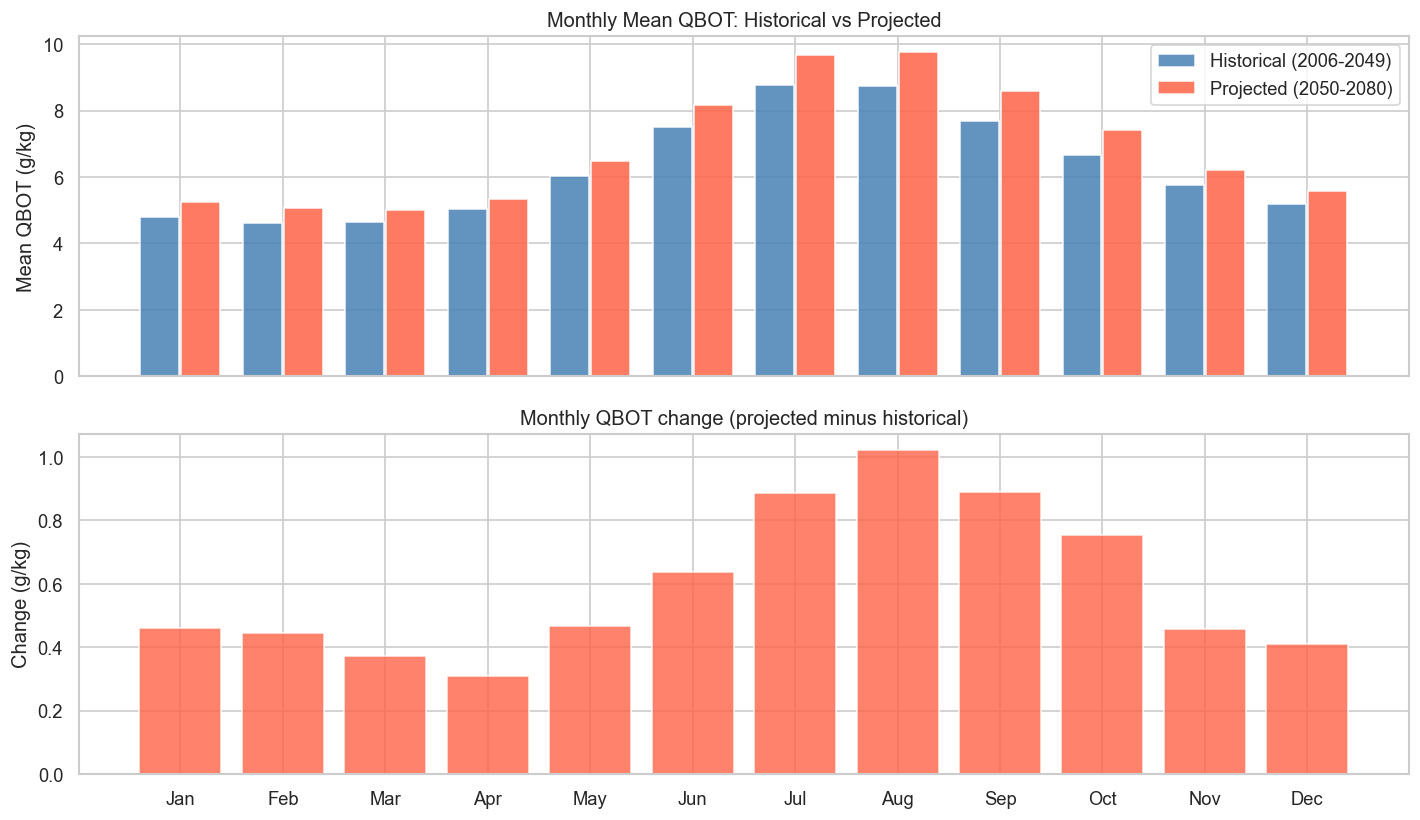


Monthly QBOT changes:
  Jan: +0.460 g/kg
  Feb: +0.445 g/kg
  Mar: +0.372 g/kg
  Apr: +0.311 g/kg
  May: +0.467 g/kg
  Jun: +0.637 g/kg
  Jul: +0.886 g/kg
  Aug: +1.021 g/kg
  Sep: +0.888 g/kg
  Oct: +0.753 g/kg
  Nov: +0.457 g/kg
  Dec: +0.411 g/kg


In [29]:
# ============================================================
# QBOT EDA: Seasonal Cycle
# ============================================================
# Purpose:
#   Compare monthly mean QBOT between the historical and projected periods.
# Key variables:
#   - `qbot_hist_monthly`, `qbot_proj_monthly`: monthly means
#   - `qbot_shift`: projected minus historical change
# Why this step:
#   - this shows whether moistening happens year-round or mainly in certain seasons
#   - it is how we identify the stronger summer increase

qbot_hist_monthly = qbot_hist.groupby("month")["QBOT_gkg"].mean()
qbot_proj_monthly = qbot_proj.groupby("month")["QBOT_gkg"].mean()
qbot_shift = qbot_proj_monthly - qbot_hist_monthly

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

x = np.arange(1, 13)
axes[0].bar(x - 0.2, qbot_hist_monthly, 0.38, label="Historical (2006-2049)", color="steelblue", alpha=0.85)
axes[0].bar(x + 0.2, qbot_proj_monthly, 0.38, label="Projected (2050-2080)", color="tomato", alpha=0.85)
axes[0].set_ylabel("Mean QBOT (g/kg)")
axes[0].set_title("Monthly Mean QBOT: Historical vs Projected")
axes[0].legend()

axes[1].bar(x, qbot_shift, color="tomato", alpha=0.8)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("Change (g/kg)")
axes[1].set_title("Monthly QBOT change (projected minus historical)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(QBOT_MONTH_NAMES)

plt.tight_layout()
plt.savefig("qbot_04_seasonal_cycle.png", dpi=150)
plt.show()

print("\nMonthly QBOT changes:")
for m, name in enumerate(QBOT_MONTH_NAMES, 1):
    print(f"  {name}: {qbot_shift[m]:+.3f} g/kg")


In [30]:
# ============================================================
# QBOT EDA: Warm-Season Focus
# ============================================================
# Purpose:
#   Summarise the humidity change specifically for June to August.
# Key variables:
#   - `warm_months`: JJA months
#   - `qbot_hist_jja`, `qbot_proj_jja`: warm-season subsets
# Why this step:
#   - JJA is the season most relevant to heat stress and hot-humid conditions
#   - a short dedicated check makes the warm-season interpretation explicit

warm_months = [6, 7, 8]
qbot_hist_jja = qbot_hist[qbot_hist["month"].isin(warm_months)]["QBOT_gkg"]
qbot_proj_jja = qbot_proj[qbot_proj["month"].isin(warm_months)]["QBOT_gkg"]
qbot_jja_abs_change_gkg = qbot_proj_jja.mean() - qbot_hist_jja.mean()
qbot_jja_pct_change = 100 * qbot_jja_abs_change_gkg / qbot_hist_jja.mean()

print("\nWarm-season (JJA) QBOT change:")
print(f"  Historical JJA mean: {qbot_hist_jja.mean():.3f} g/kg")
print(f"  Projected JJA mean:  {qbot_proj_jja.mean():.3f} g/kg")
print(f"  Absolute change:     {qbot_jja_abs_change_gkg:+.3f} g/kg")
print(f"  Relative change:     {qbot_jja_pct_change:+.2f}%")



Warm-season (JJA) QBOT change:
  Historical JJA mean: 8.349 g/kg
  Projected JJA mean:  9.200 g/kg
  Absolute change:     +0.850 g/kg
  Relative change:     +10.19%


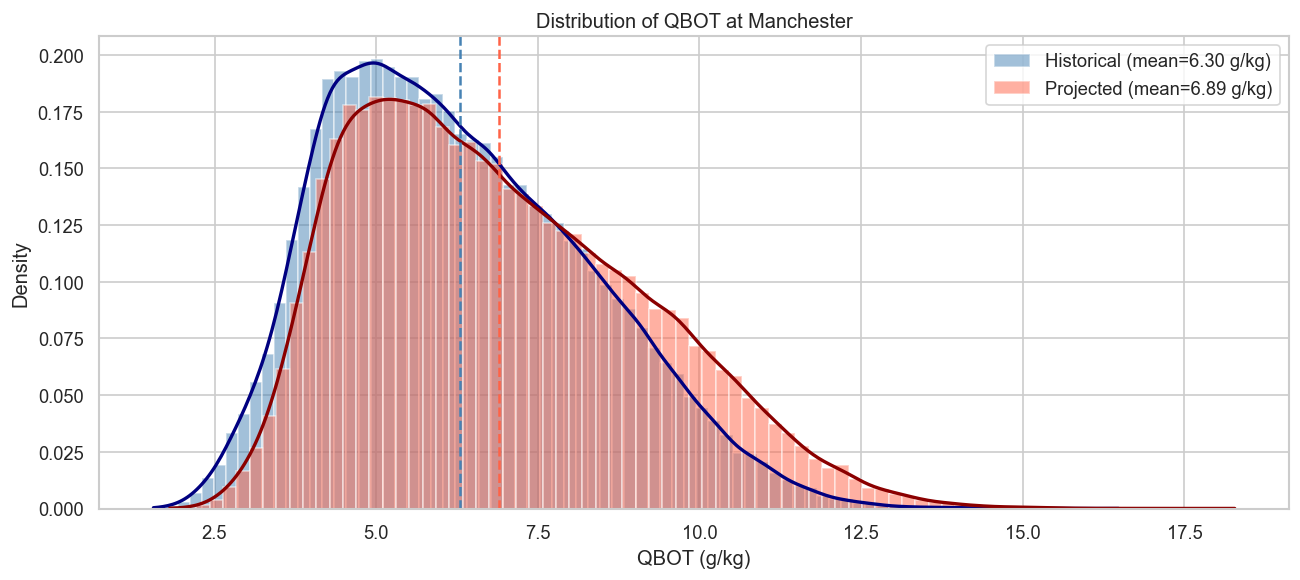

Mean shift: +0.594 g/kg
Welch t-test: t=-55.29, p=0.00e+00  (significant: True)


In [31]:
# ============================================================
# QBOT EDA: Distribution Shift
# ============================================================
# Purpose:
#   Compare the full historical and projected QBOT distributions.
# Key variables:
#   - `qbot_hist_vals`, `qbot_proj_vals`: daily humidity samples
#   - `qbot_t_stat`, `qbot_p_val`: significance test results
# Why this step:
#   - distribution plots show that the whole humidity state shifts, not only the mean
#   - this is the basis for describing the future distribution as shifted to higher values

qbot_hist_vals = qbot_hist["QBOT_gkg"].dropna()
qbot_proj_vals = qbot_proj["QBOT_gkg"].dropna()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(
    qbot_hist_vals, bins=80, alpha=0.5, color="steelblue", density=True,
    label=f"Historical (mean={qbot_hist_vals.mean():.2f} g/kg)"
)
ax.hist(
    qbot_proj_vals, bins=80, alpha=0.5, color="tomato", density=True,
    label=f"Projected (mean={qbot_proj_vals.mean():.2f} g/kg)"
)

for vals, col in [(qbot_hist_vals, "navy"), (qbot_proj_vals, "darkred")]:
    kde = gaussian_kde(vals)
    xs = np.linspace(vals.min(), vals.max(), 400)
    ax.plot(xs, kde(xs), color=col, lw=2)

ax.axvline(qbot_hist_vals.mean(), color="steelblue", ls="--", lw=1.5)
ax.axvline(qbot_proj_vals.mean(), color="tomato", ls="--", lw=1.5)
ax.set_title("Distribution of QBOT at Manchester")
ax.set_xlabel("QBOT (g/kg)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("qbot_05_distribution.png", dpi=150)
plt.show()

qbot_t_stat, qbot_p_val = stats.ttest_ind(qbot_hist_vals, qbot_proj_vals, equal_var=False)
print(f"Mean shift: {qbot_proj_vals.mean() - qbot_hist_vals.mean():+.3f} g/kg")
print(f"Welch t-test: t={qbot_t_stat:.2f}, p={qbot_p_val:.2e}  (significant: {qbot_p_val < 0.05})")


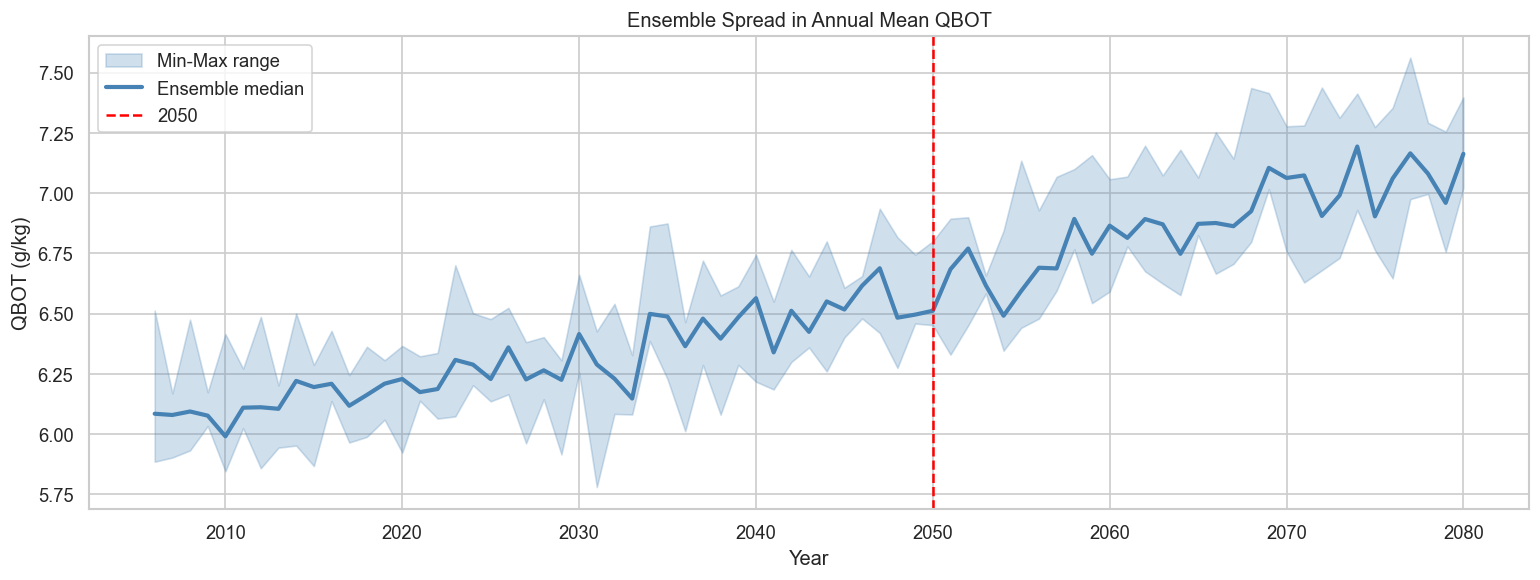

Spread in projected period: mean 0.487 g/kg, max 0.758 g/kg


In [32]:
# ============================================================
# QBOT EDA: Ensemble Spread
# ============================================================
# Purpose:
#   Show the range across ensemble members for annual mean QBOT.
# Key variables:
#   - `qbot_ann_pivot`: annual QBOT by member
#   - `qbot_ann_min`, `qbot_ann_max`, `qbot_ann_med`: spread summaries
# Why this step:
#   - spread visualises internal variability around the ensemble signal
#   - it supports the statement that the moistening signal is stronger than the noise

qbot_ann_pivot = qbot_annual.pivot(index="year", columns="member", values="ann_mean")
qbot_ann_min = qbot_ann_pivot.min(axis=1)
qbot_ann_max = qbot_ann_pivot.max(axis=1)
qbot_ann_med = qbot_ann_pivot.median(axis=1)

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(qbot_ann_pivot.index, qbot_ann_min, qbot_ann_max, alpha=0.25, color="steelblue", label="Min-Max range")
ax.plot(qbot_ann_pivot.index, qbot_ann_med, color="steelblue", lw=2.5, label="Ensemble median")
ax.axvline(2050, color="red", ls="--", lw=1.5, label="2050")
ax.set_title("Ensemble Spread in Annual Mean QBOT")
ax.set_xlabel("Year")
ax.set_ylabel("QBOT (g/kg)")
ax.legend()
plt.tight_layout()
plt.savefig("qbot_06_ensemble_spread.png", dpi=150)
plt.show()

qbot_spread_proj = qbot_ann_max[qbot_ann_max.index >= 2050] - qbot_ann_min[qbot_ann_min.index >= 2050]
print(f"Spread in projected period: mean {qbot_spread_proj.mean():.3f} g/kg, max {qbot_spread_proj.max():.3f} g/kg")


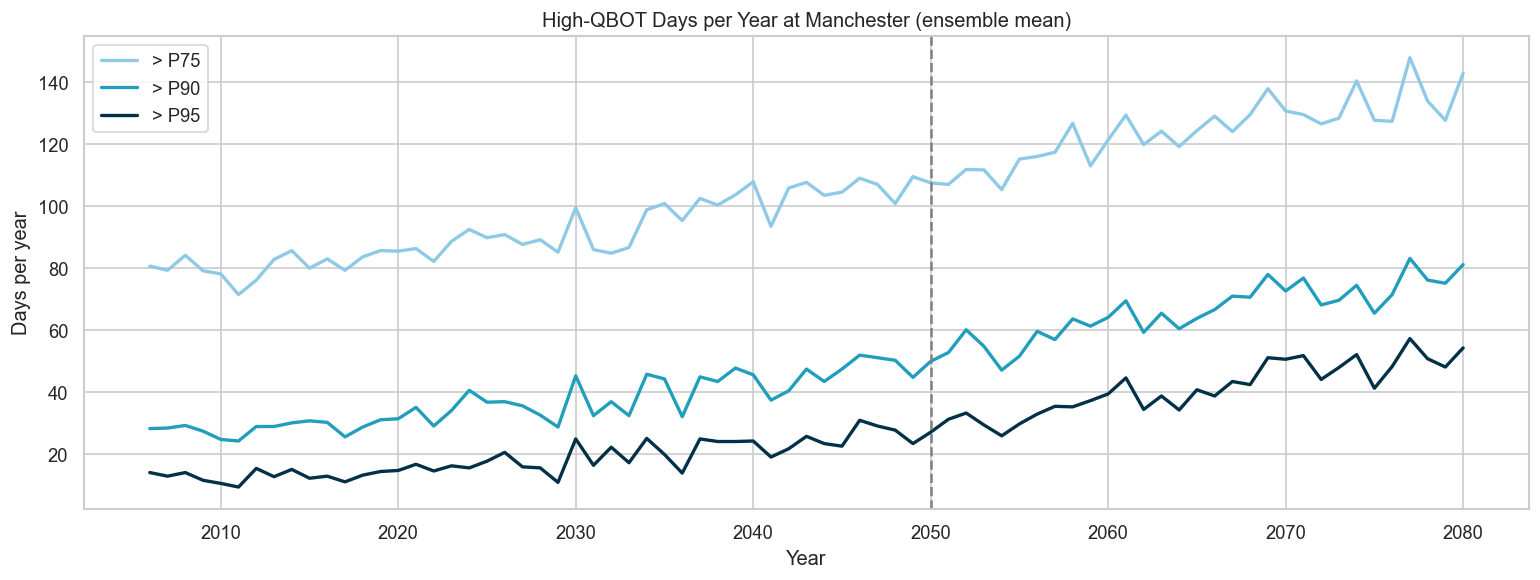


High-QBOT days per year (ensemble mean):
  > P75:  hist=91.2/yr  proj=124.3/yr  change=+33.0
  > P90:  hist=36.5/yr  proj=65.9/yr  change=+29.4
  > P95:  hist=18.2/yr  proj=41.1/yr  change=+22.9


In [33]:
# ============================================================
# QBOT EDA: High-Humidity Days
# ============================================================
# Purpose:
#   Count how often QBOT exceeds historical P75, P90, and P95 thresholds.
# Key variables:
#   - `qbot_thresholds`: historical percentile cutoffs
#   - `qbot_counts`: annual high-humidity day counts
# Why this step:
#   - humidity has no universally intuitive absolute threshold, so percentile cutoffs are more defensible
#   - this converts a mean change into an event-frequency result

qbot_thresholds = {
    "P75": qbot_hist["QBOT_gkg"].quantile(0.75),
    "P90": qbot_hist["QBOT_gkg"].quantile(0.90),
    "P95": qbot_hist["QBOT_gkg"].quantile(0.95),
}
qbot_colors = ["#8ecae6", "#219ebc", "#023047"]

fig, ax = plt.subplots(figsize=(13, 5))
for (label, thresh), col in zip(qbot_thresholds.items(), qbot_colors):
    qbot_event_mask = data["QBOT_gkg"] > thresh
    qbot_counts = (
        data.assign(qbot_event=qbot_event_mask.astype(int))
        .groupby(["member", "year"])["qbot_event"]
        .sum()
        .reset_index(name="high_qbot_days")
    )
    by_year = qbot_counts.groupby("year")["high_qbot_days"].mean()
    ax.plot(by_year.index, by_year.values, color=col, lw=2, label=f"> {label}")

ax.axvline(2050, color="grey", ls="--", lw=1.5)
ax.set_title("High-QBOT Days per Year at Manchester (ensemble mean)")
ax.set_xlabel("Year")
ax.set_ylabel("Days per year")
ax.legend()
plt.tight_layout()
plt.savefig("qbot_07_high_qbot_days.png", dpi=150)
plt.show()

print("\nHigh-QBOT days per year (ensemble mean):")
for label, thresh in qbot_thresholds.items():
    qbot_event_mask = data["QBOT_gkg"] > thresh
    qbot_counts = (
        data.assign(qbot_event=qbot_event_mask.astype(int))
        .groupby(["member", "year"])["qbot_event"]
        .sum()
        .reset_index(name="high_qbot_days")
    )
    h = qbot_counts[qbot_counts["year"] <= 2049]["high_qbot_days"].mean()
    p = qbot_counts[qbot_counts["year"] >= 2050]["high_qbot_days"].mean()
    print(f"  > {label}:  hist={h:.1f}/yr  proj={p:.1f}/yr  change={p-h:+.1f}")


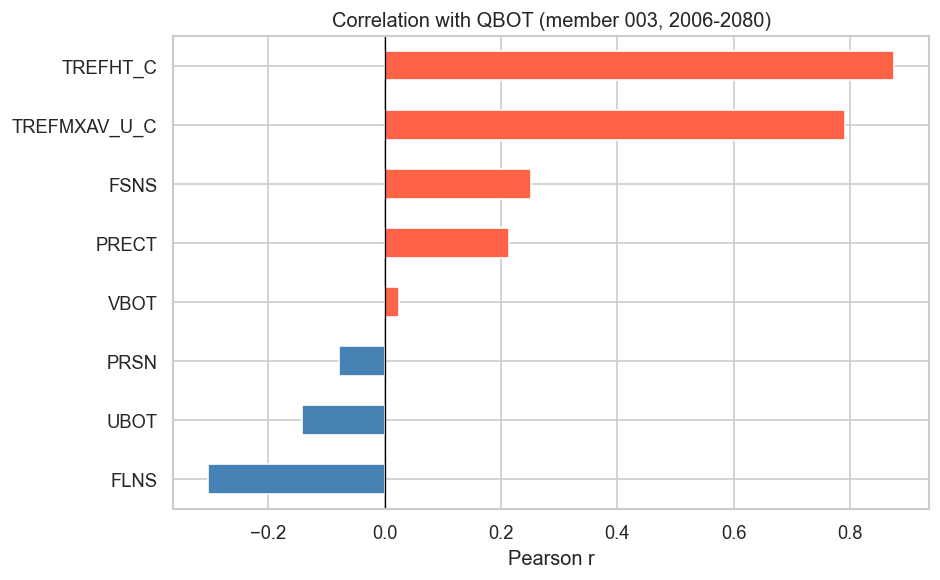


Correlations with QBOT:
  TREFHT_C    : r = +0.8762
  TREFMXAV_U_C: r = +0.7916
  FLNS        : r = -0.3045
  FSNS        : r = +0.2515
  PRECT       : r = +0.2136
  UBOT        : r = -0.1425
  PRSN        : r = -0.0780
  VBOT        : r = +0.0239


In [34]:
# ============================================================
# QBOT EDA: Correlations With Other Variables
# ============================================================
# Purpose:
#   Measure how strongly QBOT co-varies with temperature and the other climate variables.
# Key variables:
#   - `qbot_corr_vars`: variables compared with QBOT
#   - `qbot_corr_df`: sorted correlation values
# Why this step:
#   - this helps interpret the humidity system before modelling
#   - it also explains why temperature becomes an informative predictor later

qbot_corr_vars = ["TREFMXAV_U_C", "FSNS", "FLNS", "UBOT", "VBOT", "PRECT", "PRSN"]
if "TREFHT_C" in data.columns:
    qbot_corr_vars.insert(1, "TREFHT_C")
elif "TREFHT" in data.columns:
    qbot_corr_vars.insert(1, "TREFHT")

qbot_member0 = data[data["member"] == MEMBER_IDS[0]].copy()

qbot_corrs = {}
for v in qbot_corr_vars:
    if v in qbot_member0.columns:
        r = np.corrcoef(qbot_member0["QBOT_gkg"], qbot_member0[v])[0, 1]
        qbot_corrs[v] = round(r, 4)

if len(qbot_corrs) > 0:
    qbot_corr_df = pd.Series(qbot_corrs).sort_values()

    fig, ax = plt.subplots(figsize=(8, 5))
    qbot_colors_bar = ["tomato" if v > 0 else "steelblue" for v in qbot_corr_df.values]
    qbot_corr_df.plot(kind="barh", ax=ax, color=qbot_colors_bar)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(f"Correlation with QBOT (member {MEMBER_IDS[0]}, 2006-2080)")
    ax.set_xlabel("Pearson r")
    plt.tight_layout()
    plt.savefig("qbot_08_correlations.png", dpi=150)
    plt.show()

    print("\nCorrelations with QBOT:")
    for v, r in sorted(qbot_corrs.items(), key=lambda x: -abs(x[1])):
        print(f"  {v:12s}: r = {r:+.4f}")
else:
    print("\nNo correlation variables found for QBOT.")


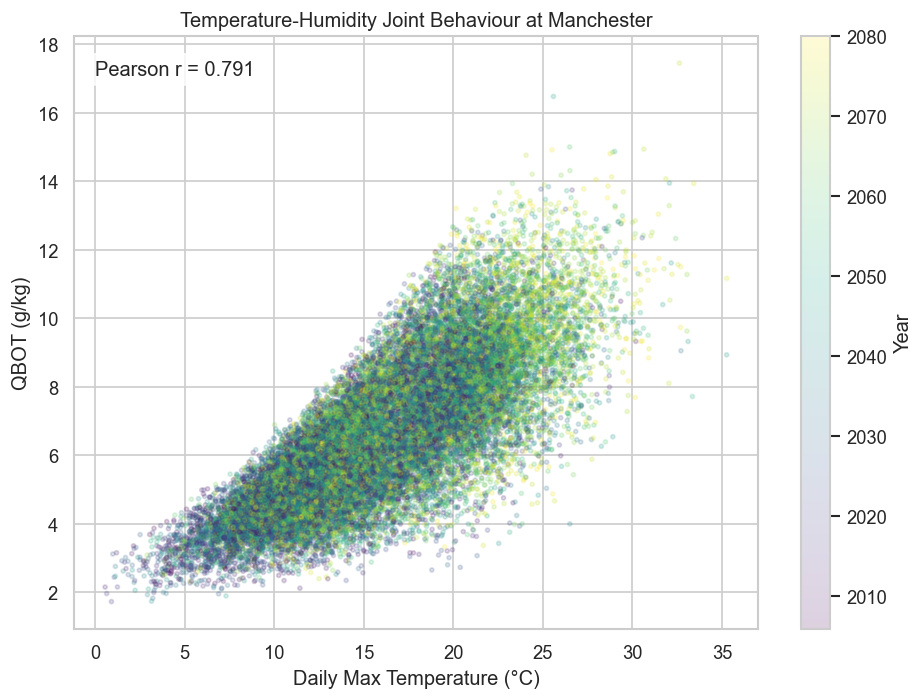

In [35]:
# ============================================================
# QBOT EDA: Temperature-Humidity Joint Plot
# ============================================================
# Purpose:
#   Plot daily Tmax against QBOT to show how heat and humidity co-occur.
# Key variables:
#   - `joint_df`: sampled table of Tmax, QBOT, and year
#   - `joint_r`: correlation between Tmax and QBOT
# Why this step:
#   - the joint plot is the clearest visual link between heat and humidity
#   - it supports the claim that later years shift toward hotter and more humid conditions

if "TREFMXAV_U_C" in data.columns:
    joint_df = data[["TREFMXAV_U_C", "QBOT_gkg", "year"]].dropna().copy()
    if len(joint_df) > 30000:
        joint_df = joint_df.sample(30000, random_state=42)

    joint_r = np.corrcoef(joint_df["TREFMXAV_U_C"], joint_df["QBOT_gkg"])[0, 1]

    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(
        joint_df["TREFMXAV_U_C"],
        joint_df["QBOT_gkg"],
        c=joint_df["year"],
        cmap="viridis",
        s=6,
        alpha=0.18,
        rasterized=True,
    )
    ax.set_xlabel("Daily Max Temperature (°C)")
    ax.set_ylabel("QBOT (g/kg)")
    ax.set_title("Temperature-Humidity Joint Behaviour at Manchester")
    ax.text(
        0.03,
        0.96,
        f"Pearson r = {joint_r:.3f}",
        transform=ax.transAxes,
        va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Year")
    plt.tight_layout()
    plt.savefig("qbot_09_temp_humidity_joint.png", dpi=150)
    plt.show()


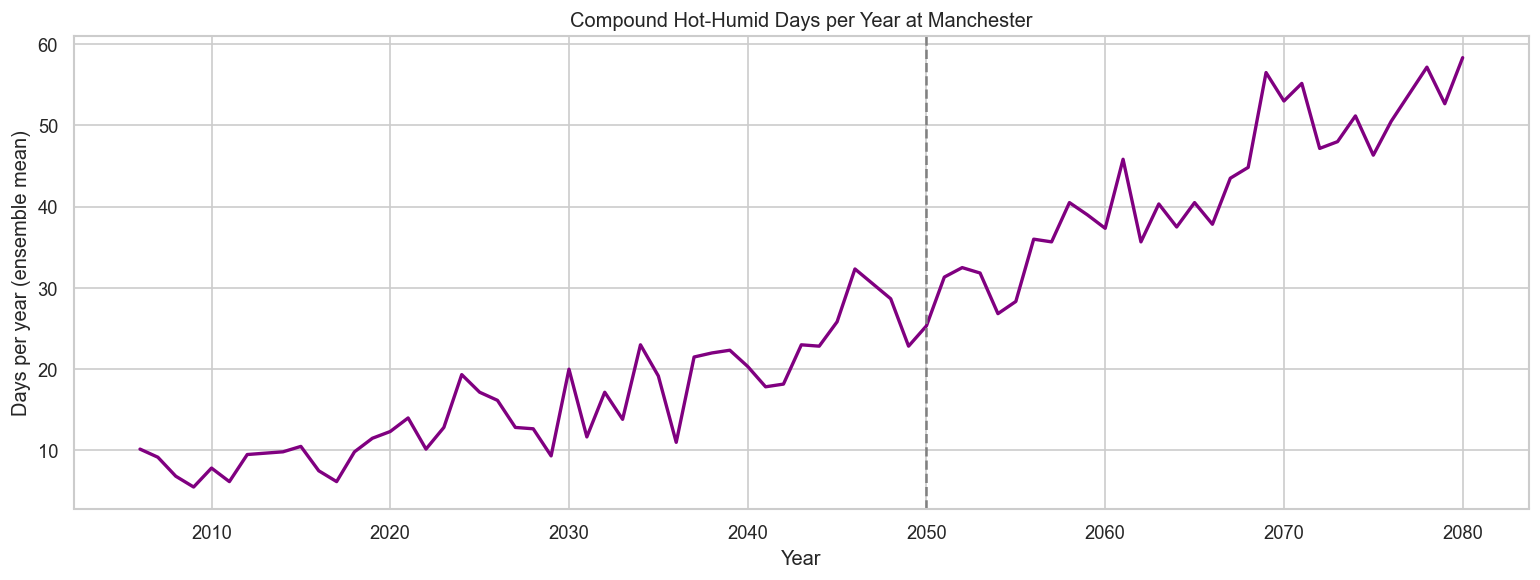


Compound hot-humid event diagnostics:
  Hot threshold (historical P90 Tmax):   21.71 °C
  Humid threshold (historical P90 QBOT): 9.119 g/kg
  Historical compound days: 15.48/yr
  Projected compound days:  42.60/yr
  Change:                   +27.12/yr


In [36]:
# ============================================================
# QBOT EDA: Compound Hot-Humid Events
# ============================================================
# Purpose:
#   Count days that are simultaneously hot and humid using historical P90 thresholds.
# Key variables:
#   - `hot_thresh`, `humid_thresh`: historical thresholds
#   - `compound_counts`: annual counts for each member-year
# Why this step:
#   - compound events are more relevant to risk than temperature or humidity alone
#   - counting all member-years, including zero-event years, avoids overstating the average frequency

if "TREFMXAV_U_C" in data.columns:
    hot_thresh = qbot_hist["TREFMXAV_U_C"].quantile(0.90)
    humid_thresh = qbot_hist["QBOT_gkg"].quantile(0.90)

    compound_mask = (
        (data["TREFMXAV_U_C"] > hot_thresh)
        & (data["QBOT_gkg"] > humid_thresh)
    )

    compound_counts = (
        data.assign(compound_event=compound_mask.astype(int))
        .groupby(["member", "year"])["compound_event"]
        .sum()
        .reset_index(name="compound_days")
    )
    compound_by_year = compound_counts.groupby("year")["compound_days"].mean()

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(compound_by_year.index, compound_by_year.values, color="purple", lw=2)
    ax.axvline(2050, color="grey", ls="--", lw=1.5)
    ax.set_title("Compound Hot-Humid Days per Year at Manchester")
    ax.set_xlabel("Year")
    ax.set_ylabel("Days per year (ensemble mean)")
    plt.tight_layout()
    plt.savefig("qbot_10_compound_hot_humid_days.png", dpi=150)
    plt.show()

    compound_hist = compound_counts[compound_counts["year"] <= 2049]["compound_days"].mean()
    compound_proj = compound_counts[compound_counts["year"] >= 2050]["compound_days"].mean()

    print("\nCompound hot-humid event diagnostics:")
    print(f"  Hot threshold (historical P90 Tmax):   {hot_thresh:.2f} °C")
    print(f"  Humid threshold (historical P90 QBOT): {humid_thresh:.3f} g/kg")
    print(f"  Historical compound days: {compound_hist:.2f}/yr")
    print(f"  Projected compound days:  {compound_proj:.2f}/yr")
    print(f"  Change:                   {compound_proj - compound_hist:+.2f}/yr")


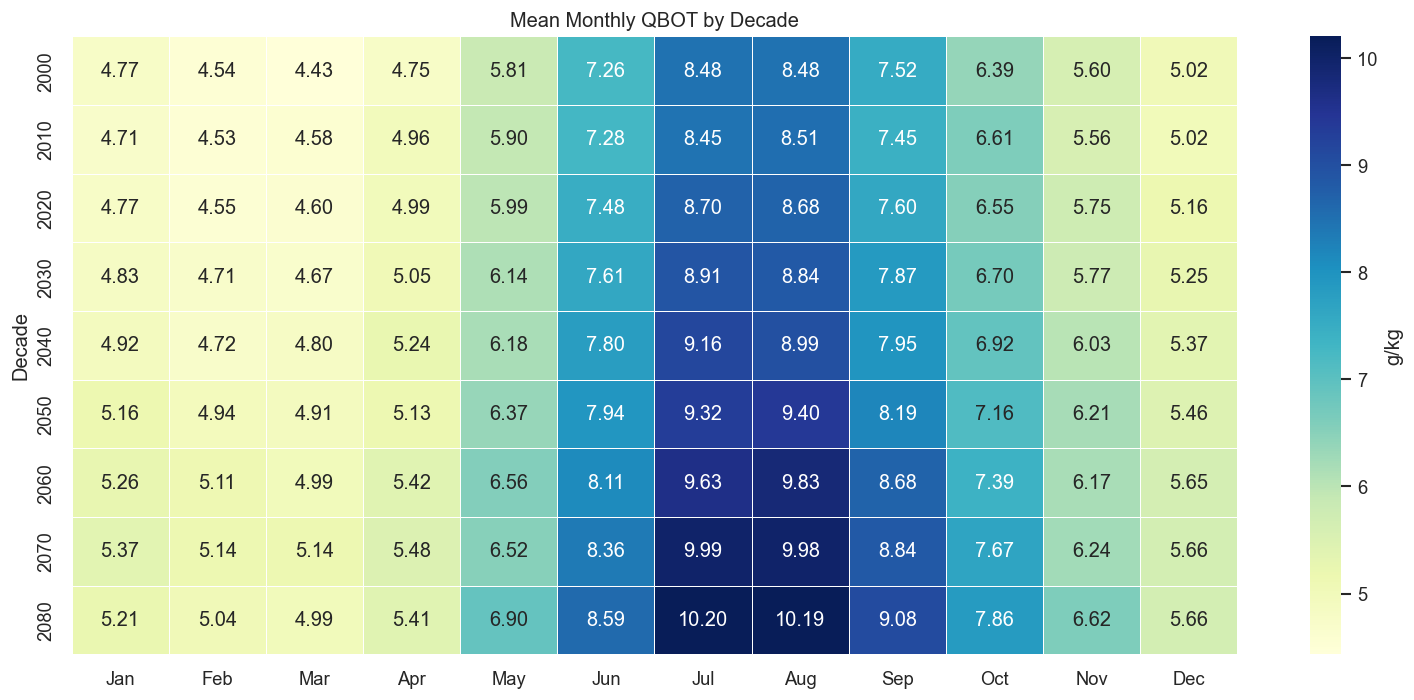


QBOT EDA done.


In [37]:
# ============================================================
# QBOT EDA: Decade-by-Month Heatmap
# ============================================================
# Purpose:
#   Summarise how average monthly QBOT changes across decades.
# Key variables:
#   - `qbot_hmap`: decade-by-month table of mean QBOT
# Why this step:
#   - the heatmap compresses long-term moisture evolution into one overview
#   - it makes seasonal and decadal structure easy to compare at a glance

if "decade" not in data.columns:
    data["decade"] = (data["year"] // 10) * 10

qbot_hmap = data.groupby(["decade", "month"])["QBOT_gkg"].mean().unstack("month")
qbot_hmap.columns = QBOT_MONTH_NAMES

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    qbot_hmap,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    ax=ax,
    linewidths=0.4,
    cbar_kws={"label": "g/kg"}
)
ax.set_title("Mean Monthly QBOT by Decade")
ax.set_ylabel("Decade")
plt.tight_layout()
plt.savefig("qbot_11_decade_heatmap.png", dpi=150)
plt.show()

print("\nQBOT EDA done.")


In [38]:
# ============================================================
# QBOT ML: Model Setup And Training
# ============================================================
# Purpose:
#   Prepare QBOT features, split the historical and future periods, train the candidate models, and build the best-model prediction table.
# Key variables:
#   - `QBOT_FEATURE_VARS`, `QBOT_FEATURE_COLS`: humidity-model predictors
#   - `qbot_train`, `qbot_test`: historical and future subsets
#   - `qbot_results`: metrics and predictions for each model
#   - `qbot_test_df`: future table with observed and predicted QBOT
# Why this step:
#   - this mirrors the Tmax workflow so the two target variables can be compared fairly
#   - keeping training and testing separate by time is important for future-period generalisation

if "QBOT" not in data.columns:
    raise ValueError("Missing QBOT column for QBOT model diagnostics.")

if "sin_doy" not in data.columns:
    data["sin_doy"] = np.sin(2 * np.pi * data["doy"] / 365.25)
if "cos_doy" not in data.columns:
    data["cos_doy"] = np.cos(2 * np.pi * data["doy"] / 365.25)
if "year_norm" not in data.columns:
    data["year_norm"] = (data["year"] - data["year"].min()) / (data["year"].max() - data["year"].min())

QBOT_FEATURE_VARS = ["TREFMXAV_U_C", "TREFHT", "FSNS", "FLNS", "UBOT", "VBOT", "PRECT", "PRSN"]
QBOT_FEATURE_COLS = QBOT_FEATURE_VARS + ["sin_doy", "cos_doy", "year_norm"]

qbot_train = data[data["year"] <= 2049].copy()
qbot_test = data[data["year"] >= 2050].copy()

qbot_X_train = qbot_train[QBOT_FEATURE_COLS].values
qbot_y_train = qbot_train["QBOT"].values
qbot_X_test = qbot_test[QBOT_FEATURE_COLS].values
qbot_y_test = qbot_test["QBOT"].values

qbot_scaler = StandardScaler()
qbot_X_train_s = qbot_scaler.fit_transform(qbot_X_train)
qbot_X_test_s = qbot_scaler.transform(qbot_X_test)

qbot_models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42,
    ),
}

qbot_results = {}
for name, model in qbot_models.items():
    print(f"\nTraining QBOT {name}...")
    Xtr = qbot_X_train_s if name == "Ridge Regression" else qbot_X_train
    Xte = qbot_X_test_s if name == "Ridge Regression" else qbot_X_test

    model.fit(Xtr, qbot_y_train)
    preds = model.predict(Xte)

    mae = mean_absolute_error(qbot_y_test, preds)
    rmse = np.sqrt(mean_squared_error(qbot_y_test, preds))
    r2 = r2_score(qbot_y_test, preds)

    qbot_results[name] = {
        "model": model,
        "preds": preds,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

qbot_best_name = max(qbot_results, key=lambda k: qbot_results[k]["R2"])
qbot_best_preds = qbot_results[qbot_best_name]["preds"]
qbot_test_df = qbot_test.copy()
qbot_test_df["predicted_qbot"] = qbot_best_preds

qbot_test_df = qbot_test_df.copy()
qbot_test_df["QBOT_gkg"] = qbot_test_df["QBOT"] * 1000.0
qbot_test_df["predicted_qbot_gkg"] = qbot_test_df["predicted_qbot"] * 1000.0

qbot_best_metrics = qbot_results[qbot_best_name]
qbot_mean_qbot = qbot_test_df["QBOT"].mean()

qbot_skill_summary = pd.DataFrame(
    [
        {
            "best_model": qbot_best_name,
            "MAE (kg/kg)": qbot_best_metrics["MAE"],
            "MAE (g/kg)": qbot_best_metrics["MAE"] * 1000.0,
            "RMSE (kg/kg)": qbot_best_metrics["RMSE"],
            "RMSE (g/kg)": qbot_best_metrics["RMSE"] * 1000.0,
            "R²": qbot_best_metrics["R2"],
            "Mean QBOT (kg/kg)": qbot_mean_qbot,
            "Mean QBOT (g/kg)": qbot_mean_qbot * 1000.0,
            "MAE as % of mean": 100 * qbot_best_metrics["MAE"] / qbot_mean_qbot,
            "RMSE as % of mean": 100 * qbot_best_metrics["RMSE"] / qbot_mean_qbot,
        }
    ]
)

print("\nReadable QBOT skill summary:")
print(qbot_skill_summary.round(4).to_string(index=False))
qbot_skill_summary.to_csv("qbot_model_skill_summary.csv", index=False)



Training QBOT Ridge Regression...

Training QBOT Random Forest...

Training QBOT Gradient Boosting...

Readable QBOT skill summary:
       best_model  MAE (kg/kg)  MAE (g/kg)  RMSE (kg/kg)  RMSE (g/kg)     R²  Mean QBOT (kg/kg)  Mean QBOT (g/kg)  MAE as % of mean  RMSE as % of mean
Gradient Boosting       0.0004      0.3907        0.0005        0.536 0.9425             0.0069            6.8936            5.6672             7.7746



Seasonal QBOT skill:
season  samples  MAE (kg/kg)  MAE (g/kg)  RMSE (kg/kg)  RMSE (g/kg)     R²
   DJF    16740       0.0003      0.2559        0.0003       0.3306 0.9249
   MAM    17112       0.0004      0.3581        0.0005       0.4859 0.8947
   JJA    17112       0.0005      0.5482        0.0007       0.7203 0.8358
   SON    16926       0.0004      0.3977        0.0005       0.5299 0.9168


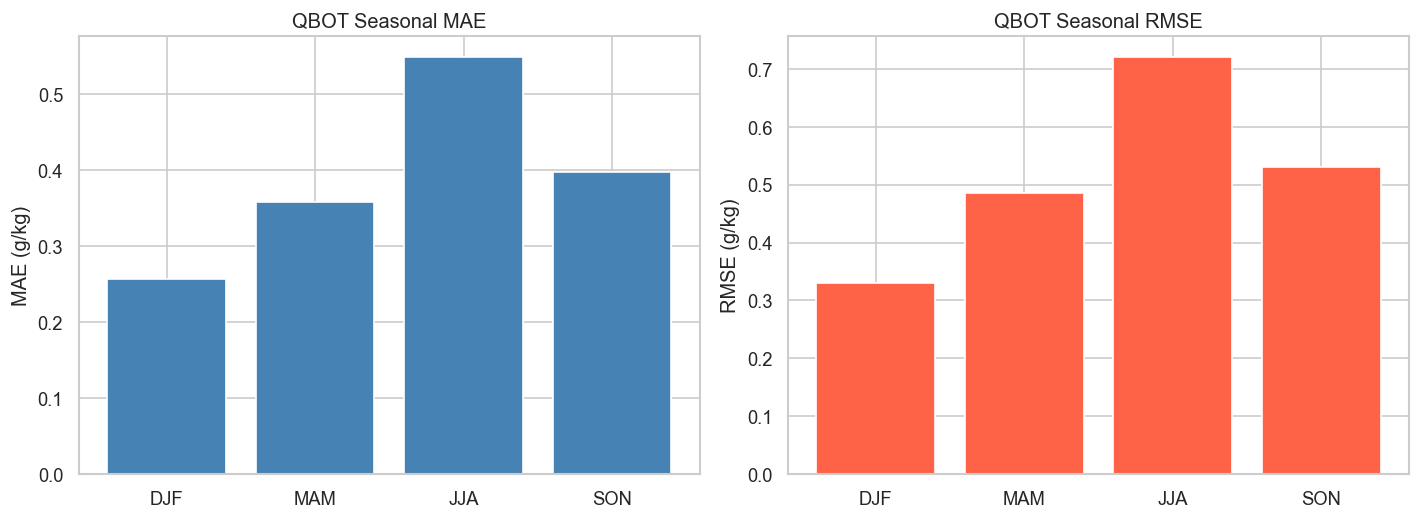

In [39]:
# ============================================================
# QBOT ML: Seasonal Skill Diagnostics
# ============================================================
# Purpose:
#   Measure how QBOT prediction skill changes by season and export the seasonal summary.
# Key variables:
#   - `season_map`: month-to-season conversion
#   - `qbot_seasonal_skill_df`: seasonal MAE, RMSE, and R² table
# Why this step:
#   - overall model metrics can hide seasonal weaknesses
#   - this section checks whether warm-season humidity is harder to predict than winter humidity

season_map = {
    12: "DJF", 1: "DJF", 2: "DJF",
    3: "MAM", 4: "MAM", 5: "MAM",
    6: "JJA", 7: "JJA", 8: "JJA",
    9: "SON", 10: "SON", 11: "SON",
}
season_order = ["DJF", "MAM", "JJA", "SON"]
qbot_test_df["season"] = qbot_test_df["month"].map(season_map)

season_rows = []
for season, grp in qbot_test_df.groupby("season"):
    mae = mean_absolute_error(grp["QBOT"], grp["predicted_qbot"])
    rmse = np.sqrt(mean_squared_error(grp["QBOT"], grp["predicted_qbot"]))
    r2 = r2_score(grp["QBOT"], grp["predicted_qbot"])
    season_rows.append(
        {
            "season": season,
            "samples": len(grp),
            "MAE (kg/kg)": mae,
            "MAE (g/kg)": mae * 1000.0,
            "RMSE (kg/kg)": rmse,
            "RMSE (g/kg)": rmse * 1000.0,
            "R²": r2,
        }
    )

qbot_seasonal_skill_df = pd.DataFrame(season_rows)
qbot_seasonal_skill_df["season"] = pd.Categorical(qbot_seasonal_skill_df["season"], season_order, ordered=True)
qbot_seasonal_skill_df = qbot_seasonal_skill_df.sort_values("season")

print("\nSeasonal QBOT skill:")
print(qbot_seasonal_skill_df.round(4).to_string(index=False))
qbot_seasonal_skill_df.to_csv("qbot_seasonal_skill.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(qbot_seasonal_skill_df["season"].astype(str), qbot_seasonal_skill_df["MAE (g/kg)"], color="steelblue")
axes[0].set_title("QBOT Seasonal MAE")
axes[0].set_ylabel("MAE (g/kg)")
axes[1].bar(qbot_seasonal_skill_df["season"].astype(str), qbot_seasonal_skill_df["RMSE (g/kg)"], color="tomato")
axes[1].set_title("QBOT Seasonal RMSE")
axes[1].set_ylabel("RMSE (g/kg)")
plt.tight_layout()
plt.savefig("qbot_ml_05_seasonal_skill.png", dpi=150)
plt.show()



Training QBOT ablation Ridge Regression...

Training QBOT ablation Random Forest...

Training QBOT ablation Gradient Boosting...

Best ablation QBOT model: Gradient Boosting (R²=0.9390)

QBOT ablation model performance on 2050-2080:
                   MAE (kg/kg)  RMSE (kg/kg)        R²
Ridge Regression      0.000531      0.000705  0.900454
Random Forest         0.000415      0.000565  0.935969
Gradient Boosting     0.000406      0.000552  0.938973

QBOT feature-set comparison:
         feature_set        best_model  n_features  MAE (g/kg)  RMSE (g/kg)     R²
   With TREFMXAV_U_C Gradient Boosting          11      0.3907       0.5360 0.9425
Without TREFMXAV_U_C Gradient Boosting          10      0.4060       0.5519 0.9390


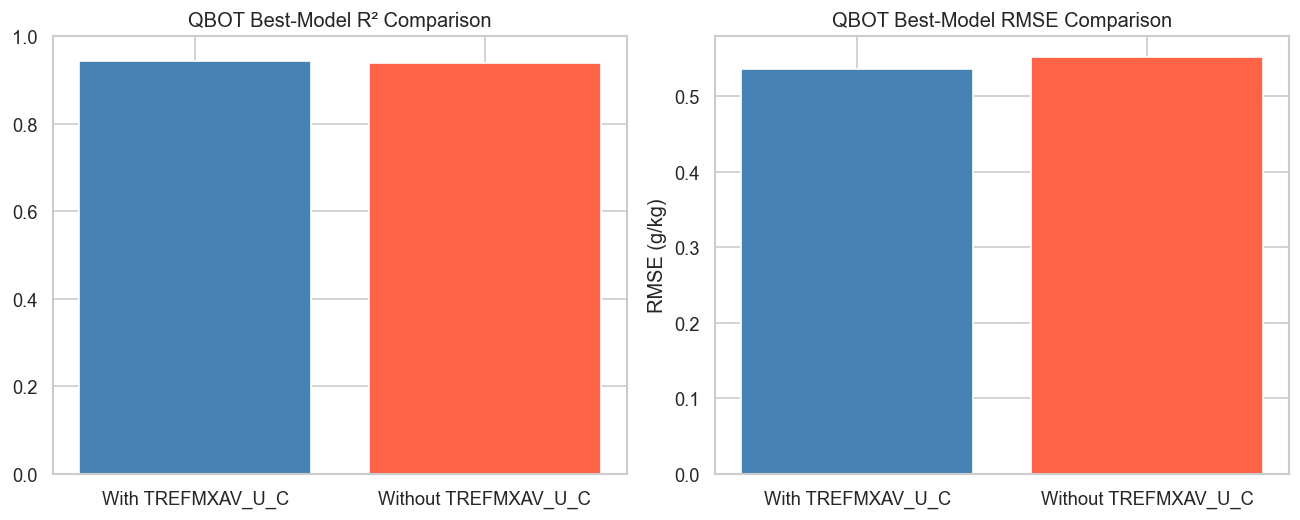


Enhanced QBOT model diagnostics done.


In [40]:
# ============================================================
# QBOT ML: Ablation Without Maximum Temperature
# ============================================================
# Purpose:
#   Repeat the QBOT model without `TREFMXAV_U_C` to test how dependent the model is on temperature information.
# Key variables:
#   - `qbot_ablation_feature_cols`: predictor list without Tmax
#   - `qbot_ablation_results`: model results for the ablation experiment
#   - `qbot_feature_set_comparison`: side-by-side comparison with and without Tmax
# Why this step:
#   - this is a direct check that temperature is helpful but not acting like a hidden shortcut
#   - ablation is more informative than feature importance alone for this question

qbot_ablation_feature_cols = [c for c in QBOT_FEATURE_COLS if c != "TREFMXAV_U_C"]

qbot_ablation_X_train = qbot_train[qbot_ablation_feature_cols].values
qbot_ablation_X_test = qbot_test[qbot_ablation_feature_cols].values

qbot_ablation_scaler = StandardScaler()
qbot_ablation_X_train_s = qbot_ablation_scaler.fit_transform(qbot_ablation_X_train)
qbot_ablation_X_test_s = qbot_ablation_scaler.transform(qbot_ablation_X_test)

qbot_ablation_models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42,
    ),
}

qbot_ablation_results = {}
for name, model in qbot_ablation_models.items():
    print(f"\nTraining QBOT ablation {name}...")
    Xtr = qbot_ablation_X_train_s if name == "Ridge Regression" else qbot_ablation_X_train
    Xte = qbot_ablation_X_test_s if name == "Ridge Regression" else qbot_ablation_X_test

    model.fit(Xtr, qbot_y_train)
    preds = model.predict(Xte)

    mae = mean_absolute_error(qbot_y_test, preds)
    rmse = np.sqrt(mean_squared_error(qbot_y_test, preds))
    r2 = r2_score(qbot_y_test, preds)

    qbot_ablation_results[name] = {
        "model": model,
        "preds": preds,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

qbot_ablation_best_name = max(qbot_ablation_results, key=lambda k: qbot_ablation_results[k]["R2"])
print(f"\nBest ablation QBOT model: {qbot_ablation_best_name} (R²={qbot_ablation_results[qbot_ablation_best_name]['R2']:.4f})")

qbot_ablation_metrics_df = pd.DataFrame(
    {
        k: {
            "MAE (kg/kg)": v["MAE"],
            "RMSE (kg/kg)": v["RMSE"],
            "R²": v["R2"],
        }
        for k, v in qbot_ablation_results.items()
    }
).T.round(6)

print("\nQBOT ablation model performance on 2050-2080:")
print(qbot_ablation_metrics_df.to_string())
qbot_ablation_metrics_df.to_csv("qbot_ablation_model_metrics.csv")

qbot_feature_set_comparison = pd.DataFrame(
    [
        {
            "feature_set": "With TREFMXAV_U_C",
            "best_model": qbot_best_name,
            "n_features": len(QBOT_FEATURE_COLS),
            "MAE (g/kg)": qbot_best_metrics["MAE"] * 1000.0,
            "RMSE (g/kg)": qbot_best_metrics["RMSE"] * 1000.0,
            "R²": qbot_best_metrics["R2"],
        },
        {
            "feature_set": "Without TREFMXAV_U_C",
            "best_model": qbot_ablation_best_name,
            "n_features": len(qbot_ablation_feature_cols),
            "MAE (g/kg)": qbot_ablation_results[qbot_ablation_best_name]["MAE"] * 1000.0,
            "RMSE (g/kg)": qbot_ablation_results[qbot_ablation_best_name]["RMSE"] * 1000.0,
            "R²": qbot_ablation_results[qbot_ablation_best_name]["R2"],
        },
    ]
)

print("\nQBOT feature-set comparison:")
print(qbot_feature_set_comparison.round(4).to_string(index=False))
qbot_feature_set_comparison.to_csv("qbot_feature_set_comparison.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(qbot_feature_set_comparison["feature_set"], qbot_feature_set_comparison["R²"], color=["steelblue", "tomato"])
axes[0].set_title("QBOT Best-Model R² Comparison")
axes[0].set_ylim(0, 1)
axes[1].bar(qbot_feature_set_comparison["feature_set"], qbot_feature_set_comparison["RMSE (g/kg)"], color=["steelblue", "tomato"])
axes[1].set_title("QBOT Best-Model RMSE Comparison")
axes[1].set_ylabel("RMSE (g/kg)")
plt.tight_layout()
plt.savefig("qbot_ml_06_ablation_compare.png", dpi=150)
plt.show()

print("\nEnhanced QBOT model diagnostics done.")


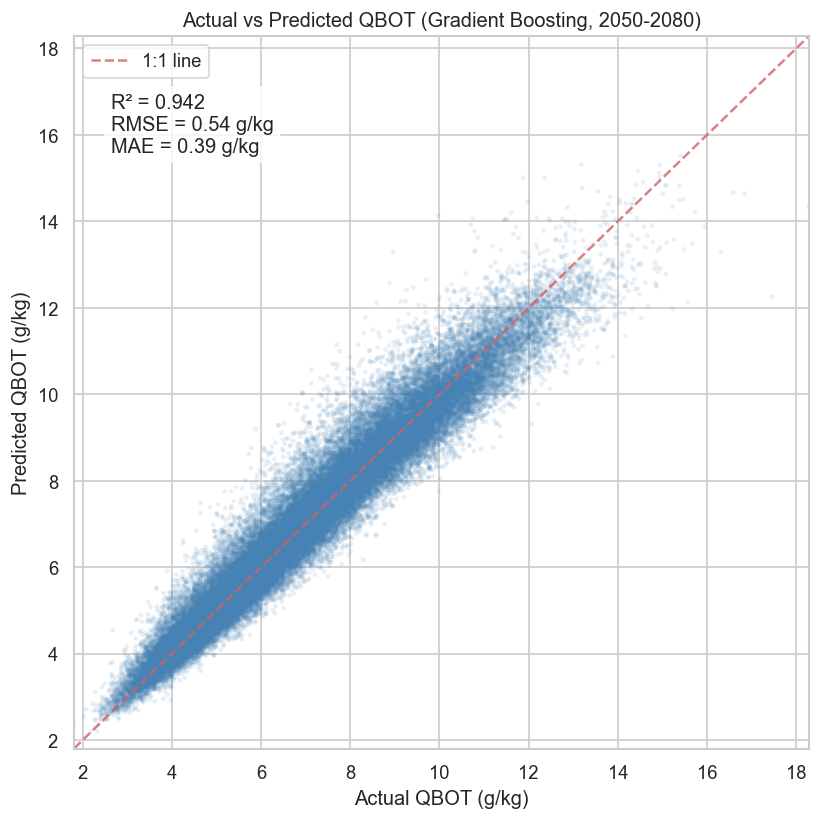

In [41]:
# ============================================================
# QBOT ML: Actual vs Predicted Scatter
# ============================================================
# Purpose:
#   Show whether predicted QBOT values match observed QBOT values in 2050-2080.
# Key variables:
#   - qbot_test_df: future-period test data with observed and predicted QBOT
#   - qbot_best_name: best QBOT model name
#   - qbot_best_metrics: stored MAE, RMSE, and R² for the best model
# Why this step:
#   - this provides a direct visual check of model prediction accuracy
#   - points close to the 1:1 line mean better prediction skill

if "QBOT_gkg" not in qbot_test_df.columns:
    qbot_test_df["QBOT_gkg"] = qbot_test_df["QBOT"] * 1000.0

if "predicted_qbot_gkg" not in qbot_test_df.columns:
    qbot_test_df["predicted_qbot_gkg"] = qbot_test_df["predicted_qbot"] * 1000.0

qbot_actual = qbot_test_df["QBOT_gkg"].values
qbot_pred = qbot_test_df["predicted_qbot_gkg"].values

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    qbot_actual,
    qbot_pred,
    s=8,
    alpha=0.12,
    color="steelblue",
    edgecolors="none",
)

lims = [
    min(qbot_actual.min(), qbot_pred.min()),
    max(qbot_actual.max(), qbot_pred.max()),
]

ax.plot(lims, lims, "r--", lw=1.5, alpha=0.8, label="1:1 line")

ax.text(
    0.05,
    0.92,
    f"R² = {qbot_best_metrics['R2']:.3f}\n"
    f"RMSE = {qbot_best_metrics['RMSE'] * 1000:.2f} g/kg\n"
    f"MAE = {qbot_best_metrics['MAE'] * 1000:.2f} g/kg",
    transform=ax.transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual QBOT (g/kg)")
ax.set_ylabel("Predicted QBOT (g/kg)")
ax.set_title(f"Actual vs Predicted QBOT ({qbot_best_name}, 2050-2080)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("qbot_ml_01_scatter.png", dpi=150)
plt.show()
